# Load Packages

In [31]:
# ==============================
# Install required packages
# ==============================
!pip install -q --upgrade pip
!pip install -q pyunpack patool rarfile rioxarray rasterio xarray

# ==============================
# Standard library
# ==============================
import os
import sys
import glob
import pathlib
import zipfile

# ==============================
# General utilities
# ==============================
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================
# Image handling
# ==============================
import PIL
from PIL import Image

# ==============================
# Raster / geospatial
# ==============================
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.windows import Window
import rioxarray as rxr

# ==============================
# Archive handling
# ==============================
import pyunpack
from rarfile import RarFile

# ==============================
# TensorFlow / Keras
# ==============================
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, Conv2DTranspose, MaxPooling2D,
    UpSampling2D, Dropout, BatchNormalization,
    Activation, concatenate, add, multiply
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import binary_crossentropy
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ==============================
# Evaluation metrics
# ==============================
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix
)


In [32]:
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [33]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
# Specify whether to download data or read in
download = True
base_dir = "./content/Iraq_Marshes_s2_water_seg/"

In [35]:
# Download data
if download:
    url = 'https://zenodo.org/records/18474639/files/Iraq_Marshes_s2_water_seg.zip?download=1'

    # download
    r = requests.get(url)
    with open("data.zip", "wb") as f:
      f.write(r.content)

    # extract
    with zipfile.ZipFile("data.zip", "r") as z:
      z.extractall("/content/")

    # confirm
    os.listdir("/content/")

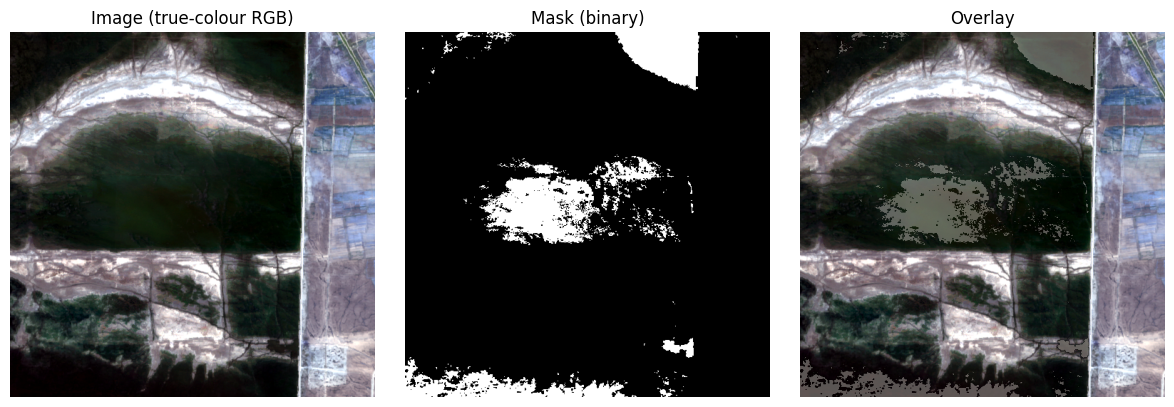

Image path: /content/Iraq_Marshes_s2_water_seg/training/rgb_png/central_marshes_2021_r004_c009.png
Mask path: /content/Iraq_Marshes_s2_water_seg/training/masks/central_marshes_2021_r004_c009.npy
Image shape: (512, 512, 3) dtype: float32
Mask shape: (512, 512) dtype: uint8 mask min/max: 0 1
Water pixel ratio: 0.10550308227539062


In [47]:
split = "training"

# Use the PNG filename for the image tile
img_fname  = "central_marshes_2021_r004_c009.png"
mask_fname = "central_marshes_2021_r004_c009.npy"  # adjust if your masks are png

img_path  = os.path.join(base_dir, split, "rgb_png", img_fname)
mask_path = os.path.join(base_dir, split, "masks",  mask_fname)

# ---- load image (PNG) ----
img = np.array(Image.open(img_path))

# If it was saved as 0-255 uint8, convert to float32
img = img.astype(np.float32)

# ---- load mask (NPY) ----
mask = np.load(mask_path)

if mask.ndim == 3 and mask.shape[-1] == 1:
    mask = mask[..., 0]

# =========================
# TRUE-COLOUR RGB (assuming band order [B2,B3,B4,B8])
# =========================
# If your PNG is already 3-channel RGB, this step should change.
# If it's 4-channel (e.g., B2,B3,B4,B8), then:
if img.ndim == 3 and img.shape[-1] >= 3:
    # If it's 4-band: RGB = [B4,B3,B2] = indices [2,1,0]
    rgb = img[..., [2, 1, 0]]
else:
    raise ValueError(f"Unexpected image shape: {img.shape}")

rgb_disp = np.zeros_like(rgb, dtype=np.float32)
for c in range(3):
    p2, p98 = np.percentile(rgb[..., c], (2, 98))
    rgb_disp[..., c] = np.clip((rgb[..., c] - p2) / (p98 - p2 + 1e-6), 0, 1)

# =========================
# MASK -> BINARY
# =========================
m = mask.astype(np.float32)
if m.max() > 1.5:  # e.g., 0/255
    m = m / 255.0
m_bin = (m > 0.5).astype(np.uint8)

# =========================
# PLOT
# =========================
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(rgb_disp)
plt.title("Image (true-colour RGB)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(m_bin, cmap="gray")
plt.title("Mask (binary)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(rgb_disp)
plt.imshow(np.ma.masked_where(m_bin == 0, m_bin), cmap="Reds", alpha=0.35)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Image path:", img_path)
print("Mask path:", mask_path)
print("Image shape:", img.shape, "dtype:", img.dtype)
print("Mask shape:", mask.shape, "dtype:", mask.dtype, "mask min/max:", mask.min(), mask.max())
print("Water pixel ratio:", float(m_bin.mean()))

# Functions

In [37]:
'''
  Returns an image plot of mask prediction
'''

def reconstruct_image(model, image, rounded=False):

  # Find model prediction
  reconstruction = model.predict(image).reshape(image.shape[1], image.shape[2])
  # Standardise between 0-1
  reconstruction = reconstruction/np.max(reconstruction)

  # Round to 0-1, binary pixel-by-pixel classification
  if rounded:
    reconstruction = np.round(reconstruction)

  # Plot reconstructed mask (prediction)
  plt.imshow(reconstruction)

In [38]:
'''
  Returns array of mask prediction, given model and image
'''
def reconstruct_array(model, image, rounded=False):

  # Find model prediction
  reconstruction = model.predict(image).reshape(image.shape[1], image.shape[2])

  if rounded:
    reconstruction = np.round(reconstruction)

  return reconstruction # Returns array

In [39]:
'''
  Metric functions for evaluation
'''

def score_eval(model, image, mask): # Gives score of mask vs prediction
  if type(image) != list:
    reconstruction = model.predict(image).reshape(mask.shape[1], mask.shape[2])
    reconstruction = np.round(reconstruction).flatten()

    return accuracy_score(mask.flatten(), reconstruction)

  else: # If a list of images input, find accuracy for each
    scores = []
    for i in range(len(image)):
      reconstruction = model.predict(image[i].reshape(1, 512, 512, 3))
      reconstruction = np.round(reconstruction).flatten()

      scores.append(accuracy_score(mask[i].flatten(), reconstruction))

    return scores

def score_eval2(model, image, mask): # Gives score of mask vs prediction
  if type(image) != list:
    reconstruction = model.predict(image).reshape(mask.shape[1], mask.shape[2])
    reconstruction = np.round(reconstruction).flatten()

    return accuracy_score(mask.flatten(), reconstruction)

  else: # If a list of images input, find accuracy for each
    scores = []
    for i in range(len(image)):
      reconstruction = model.predict(image[i].reshape(1, 512, 512, 4))
      reconstruction = np.round(reconstruction).flatten()

      scores.append(accuracy_score(mask[i].flatten(), reconstruction))

    return scores

def recall_eval(model, image, mask): # Find recall score
  if type(image) != list:
    reconstruction = model.predict(image).reshape(mask.shape[1], mask.shape[2])
    reconstruction = np.round(reconstruction).flatten()

    return recall_score(mask.flatten(), reconstruction, average='weighted')

  else: # If a list of images input, find accuracy for each
    recall = []
    for i in range(len(image)):
        reconstruction = model.predict(image[i]).reshape(mask[i].shape[1], mask[i].shape[2])
        reconstruction = np.round(reconstruction).flatten()

        recall.append(recall_score(mask[i].flatten(), reconstruction, average='weighted'))

    return recall

def precision_eval(model, image, mask): # Find precision score
  if type(image) != list:
    reconstruction = model.predict(image).reshape(mask.shape[1], mask.shape[2])
    reconstruction = np.round(reconstruction).flatten()

    return precision_score(mask.flatten(), reconstruction, average='weighted')

  else: # If a list of images input, find accuracy for each
    precision = []
    for i in range(len(image)):
        reconstruction = model.predict(image[i]).reshape(mask[i].shape[1], mask[i].shape[2])
        reconstruction = np.round(reconstruction).flatten()

        precision.append(precision_score(mask[i].flatten(), reconstruction, average='weighted'))

    return precision

def f1_score_eval(model, image, mask): # Find F1-score
    prec = np.mean(precision_eval(model, image, mask))
    rec = np.mean(recall_eval(model, image, mask))

    if prec + rec == 0:
        return 0

    return 2 * (prec * rec) / (prec + rec)

def f1_score_eval_basic(precision, recall):
    prec = np.mean(precision)
    rec = np.mean(recall)

    if prec + rec == 0:
        return 0

    return 2 * (prec * rec) / (prec + rec)

def produce_mask(image): # Outputs rounded image (binary)
  return np.round(image)

# Ingest and Process RGB Dataset

In [51]:

base_dir = "/content/Iraq_Marshes_s2_water_seg"

# ---------- TRAIN ----------
train_rgb_dir  = os.path.join(base_dir, "training", "rgb_png")
train_mask_dir = os.path.join(base_dir, "training", "masks")

training_images_list = [n for n in os.listdir(train_rgb_dir) if not os.path.isdir(os.path.join(train_rgb_dir, n))]

training_images = []
training_masks  = []

for n in training_images_list:
    img_path  = os.path.join(train_rgb_dir, n)
    mask_name = os.path.splitext(n)[0] + ".npy"
    mask_path = os.path.join(train_mask_dir, mask_name)

    im = Image.open(img_path).convert("RGB")
    training_images.append(im)

    training_masks.append(np.load(mask_path))


# ---------- VALIDATION ----------
val_rgb_dir  = os.path.join(base_dir, "validation", "rgb_png")
val_mask_dir = os.path.join(base_dir, "validation", "masks")

validation_images_list = [n for n in os.listdir(val_rgb_dir) if not os.path.isdir(os.path.join(val_rgb_dir, n))]

validation_images = []
validation_masks  = []

for n in validation_images_list:
    img_path  = os.path.join(val_rgb_dir, n)
    mask_name = os.path.splitext(n)[0] + ".npy"
    mask_path = os.path.join(val_mask_dir, mask_name)

    im = Image.open(img_path).convert("RGB")
    validation_images.append(im)

    validation_masks.append(np.load(mask_path))


# ---------- TEST ----------
test_rgb_dir = os.path.join(base_dir, "test", "rgb_png")
test_dir_fallback = os.path.join(base_dir, "test")
test_dir = test_rgb_dir if os.path.isdir(test_rgb_dir) else test_dir_fallback

test_images_list = [n for n in os.listdir(test_dir) if not os.path.isdir(os.path.join(test_dir, n))]

test_images = []
for n in test_images_list:
    path = os.path.join(test_dir, n)
    if n.lower().endswith(".npy"):
        im = np.load(path)
    else:
        im = Image.open(path).convert("RGB")
    test_images.append(im)

print("Train:", len(training_images), "Val:", len(validation_images), "Test:", len(test_images))
print("Example train img path:", os.path.join(train_rgb_dir, training_images_list[0]))

Train: 143 Val: 99 Test: 20
Example train img path: /content/Iraq_Marshes_s2_water_seg/training/rgb_png/central_marshes_2021_r007_c010.png


In [52]:
IMG_SIZE = 512

def to_pil_rgb(x):
    """Accept PIL.Image or np.ndarray and return a PIL RGB image."""
    if isinstance(x, Image.Image):
        return x.convert("RGB")

    if isinstance(x, np.ndarray):
        arr = x

        # If it's float in [0,1], convert to uint8
        if arr.dtype != np.uint8:
            # if values look like 0..1, scale up; otherwise clip
            if arr.max() <= 1.0:
                arr = (arr * 255.0).clip(0, 255).astype(np.uint8)
            else:
                arr = arr.clip(0, 255).astype(np.uint8)

        # Ensure 3 channels
        if arr.ndim == 2:
            arr = np.repeat(arr[..., None], 3, axis=-1)
        if arr.shape[-1] == 1:
            arr = np.repeat(arr, 3, axis=-1)
        if arr.shape[-1] > 3:
            arr = arr[..., :3]

        return Image.fromarray(arr, mode="RGB")

    raise TypeError(f"Unsupported type: {type(x)}")

def preprocess_img_any(x, size=IMG_SIZE):
    im = to_pil_rgb(x)
    im = im.resize((size, size), resample=Image.BILINEAR)
    return (np.asarray(im, dtype=np.float32) / 255.0)  # (512,512,3)

def preprocess_mask_npy(mask, size=IMG_SIZE):
    y = np.asarray(mask)
    if y.ndim == 3 and y.shape[-1] == 1:
        y = y[..., 0]

    # binarise (handles 0/255 or 0/1)
    y = (y > 0).astype(np.uint8)

    if y.shape[0] != size or y.shape[1] != size:
        y_img = Image.fromarray(y)
        y_img = y_img.resize((size, size), resample=Image.NEAREST)
        y = np.asarray(y_img, dtype=np.uint8)

    return y[..., None]  # (512,512,1)

# ---- apply ----
training_images   = [preprocess_img_any(im) for im in training_images]
validation_images = [preprocess_img_any(im) for im in validation_images]

training_masks    = [preprocess_mask_npy(m) for m in training_masks]
validation_masks  = [preprocess_mask_npy(m) for m in validation_masks]

# Stack into arrays
X_train = np.stack(training_images, axis=0)
Y_train = np.stack(training_masks,  axis=0)
X_val   = np.stack(validation_images, axis=0)
Y_val   = np.stack(validation_masks,  axis=0)

print("X_train:", X_train.shape, X_train.dtype, "range:", (X_train.min(), X_train.max()))
print("Y_train:", Y_train.shape, Y_train.dtype, "unique:", np.unique(Y_train)[:10])
print("X_val  :", X_val.shape, X_val.dtype)
print("Y_val  :", Y_val.shape, Y_val.dtype)

X_train: (143, 512, 512, 3) float32 range: (np.float32(0.0), np.float32(1.0))
Y_train: (143, 512, 512, 1) uint8 unique: [0 1]
X_val  : (99, 512, 512, 3) float32
Y_val  : (99, 512, 512, 1) uint8


In [53]:
print("Train image:", np.array(training_images[0]).shape)
print("Train mask :", np.array(training_masks[0]).shape, np.unique(training_masks[0])[:10])


Train image: (512, 512, 3)
Train mask : (512, 512, 1) [0 1]


In [ ]:
# Create TensorFlow datasets for validation sets
validation_df = tf.data.Dataset.from_tensor_slices((validation_images, validation_masks))

In [ ]:
#
# Data loader/generator from: https://github.com/bragagnololu/UNet-defmapping.git
#

def adjustData(img, mask, num_class):

    mask[mask > 0.5] = 1 # FOREST
    mask[mask <= 0.5] = 0 # NON-FOREST

    return (img,mask)

def trainGenerator(batch_size,
                   image_array,
                   mask_array,
                   aug_dict,
                   image_save_prefix  = "image",
                   mask_save_prefix  = "mask",
                   num_class = 2,
                   save_to_dir = None,
                   target_size = (512,512),
                   seed = 1):

    image_datagen = ImageDataGenerator(**aug_dict)
    mask_datagen = ImageDataGenerator(**aug_dict)

    image_generator = image_datagen.flow(image_array,
                                           batch_size = batch_size,
                                           save_to_dir = save_to_dir,
                                           save_prefix = image_save_prefix,
                                           seed = seed)

    mask_generator = mask_datagen.flow(mask_array,
                                           batch_size = batch_size,
                                           save_to_dir = save_to_dir,
                                           save_prefix = mask_save_prefix,
                                           seed = seed)

    train_generator = zip(image_generator, mask_generator)

    for (img,mask) in train_generator:
        img, mask = adjustData(img, mask, num_class)
        yield (img, mask)

In [ ]:
#
# Produce generators for training images
#

t_images = np.stack(training_images)
t_masks = np.stack(training_masks)

v_images = np.stack(validation_images)
v_masks = np.stack(validation_masks)

# Set parameters for data augmentation
data_gen_args = dict(rotation_range=180,
                    width_shift_range=0.25,
                    height_shift_range=0.25,
                    shear_range=0.25,
                    zoom_range=0.25,
                    horizontal_flip=True,
                    vertical_flip = True,
                    fill_mode='reflect',
                    )

train = trainGenerator(1, t_images, t_masks, data_gen_args, save_to_dir=None)

# Ingest and Process 4-band Datasets

## 4-band Marshes dataset

In [ ]:
base_dir2 = r"./content/Iraq_Marshes_s2_water_seg/"

In [ ]:
# Ingest images and normalise
def minmax_norm(a, eps=1e-8):
  a = a.astype(np.float32)
  amin = np.min(a)
  amax = np.max(a)
  return (a - amin) / (amax - amin + eps)

def ensure_mask_hw1(m):
  m = np.array(m)
  # squeeze common odd shapes
  if m.ndim == 3 and m.shape[-1] == 1:
    return m.astype(np.int32)
  if m.ndim == 3 and m.shape[0] == 1:
    m = m[0]
  if m.ndim == 2:
    m = m[..., None]
  return m.astype(np.int32)

def only_npy(files):
  return [f for f in files if f.lower().endswith(".npy")]
# =========================
# TRAIN (4-band)
# =========================
training_images_list2 = only_npy(os.listdir(rf"{base_dir2}training/images/"))[:250]
training_masks_list2  = training_images_list2[:]   # same filenames
training_images2 = []
training_masks2  = []

for n in training_images_list2:
  img = np.load(rf"{base_dir2}training/images/{n}")   # (H,W,4)
  img = minmax_norm(img)
  training_images2.append(img)

  m = np.load(rf"{base_dir2}training/masks/{n}")      # (H,W) or (H,W,1)
  training_masks2.append(ensure_mask_hw1(m))

# =========================
# VALIDATION (4-band)
# =========================
validation_images_list2 = only_npy(os.listdir(rf"{base_dir2}validation/images/"))
validation_masks_list2  = validation_images_list2[:]
validation_images2 = []
validation_masks2  = []

for n in validation_images_list2:
  img = np.load(rf"{base_dir2}validation/images/{n}")
  img = minmax_norm(img)
  validation_images2.append(img)

  m = np.load(rf"{base_dir2}validation/masks/{n}")
  validation_masks2.append(ensure_mask_hw1(m))

# =========================
# TEST (4-band)
# =========================
test_images_list2 = only_npy(os.listdir(rf"{base_dir2}test/images/"))
test_masks_list2  = test_images_list2[:]
test_images2 = []
test_masks2  = []

for n in test_images_list2:
  img = np.load(rf"{base_dir2}test/images/{n}")
  img = minmax_norm(img)
  test_images2.append(img)

  m = np.load(rf"{base_dir2}test/masks/{n}")
  test_masks2.append(ensure_mask_hw1(m))

# =========================
# Verify
# =========================
print("Training image shape:", training_images2[0].shape, "dtype:", training_images2[0].dtype)  # (H,W,4)
print("Training mask shape:", training_masks2[0].shape, "dtype:", training_masks2[0].dtype)    # (H,W,1)
print("Counts:", len(training_images2), len(validation_images2), len(test_images2))

In [ ]:
fname = "central_marshes_2021_r004_c009.npy"
base_dir = "/content/Iraq_Marshes_s2_water_seg"
split = "training"
# =========================
# 2) LOAD ONE TILE
# =========================

img_path  = os.path.join(base_dir, split, "images", fname)
mask_path = os.path.join(base_dir, split, "masks",  fname)

img  = np.load(img_path).astype(np.float32)  # (H,W,4)
mask = np.load(mask_path)

# masks might be (H,W,1)
if mask.ndim == 3 and mask.shape[-1] == 1:
    mask = mask[..., 0]

# =========================
# 3) MAKE TRUE-COLOUR RGB (B4,B3,B2) + PER-CHANNEL STRETCH
# =========================
# Assuming band order is [B2,B3,B4,B8] -> RGB = [B4,B3,B2] = indices [2,1,0]
rgb = img[..., [2, 1, 0]]

rgb_disp = np.zeros_like(rgb, dtype=np.float32)
for c in range(3):
    p2, p98 = np.percentile(rgb[..., c], (2, 98))
    rgb_disp[..., c] = np.clip((rgb[..., c] - p2) / (p98 - p2 + 1e-6), 0, 1)

# =========================
# 4) MASK -> BINARY
# =========================
m = mask.astype(np.float32)
if m.max() > 1.5:  # e.g., 0/255
    m = m / 255.0
m_bin = (m > 0.5).astype(np.uint8)

# =========================
# 5) PLOT
# =========================
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(rgb_disp)
plt.title("Image (true-colour RGB)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(m_bin, cmap="gray")
plt.title("Mask (binary)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(rgb_disp)
plt.imshow(np.ma.masked_where(m_bin == 0, m_bin), cmap="Reds", alpha=0.35)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Image shape:", img.shape, "dtype:", img.dtype)
print("Mask shape:", mask.shape, "dtype:", mask.dtype, "mask min/max:", mask.min(), mask.max())
print("Water pixel ratio:", float(m_bin.mean()))

In [ ]:
#Preporcess
# --- helpers ---
def to_rgb4_512(pil_or_arr):
  """Return float32 array (512,512,4) in [0,1]. Pads/crops as needed."""
  x = np.array(pil_or_arr)

  # ensure channel dim
  if x.ndim == 2:
    x = x[..., None]

  # if RGB -> add alpha channel
  if x.shape[-1] == 3:
    alpha = np.full((x.shape[0], x.shape[1], 1), 255, dtype=x.dtype)
    x = np.concatenate([x, alpha], axis=-1)
  elif x.shape[-1] == 1:
    x = np.repeat(x, 4, axis=-1)
  elif x.shape[-1] >= 4:
    x = x[..., :4]

  # crop/pad to 512x512
  H, W, C = x.shape
  x = x[:512, :512, :4]
  H2, W2, _ = x.shape

  if H2 < 512 or W2 < 512:
    out = np.zeros((512, 512, 4), dtype=x.dtype)
    out[:H2, :W2, :] = x
    x = out

  # normalise
  x = x.astype("float32") / 255.0
  return x

def mask_to_512_1(m):
  """Return int array (1,512,512,1). Pads/crops as needed."""
  y = np.array(m)

  # squeeze common shapes like (1,H,W) or (H,W,1)
  if y.ndim == 3 and y.shape[0] == 1:
    y = y[0]
  if y.ndim == 3 and y.shape[-1] == 1:
    y = y[..., 0]

  # now y should be (H,W)
  y = y[:512, :512]
  H, W = y.shape

  if H < 512 or W < 512:
    out = np.zeros((512, 512), dtype=y.dtype)
    out[:H, :W] = y
    y = out

  y = y.reshape(1, 512, 512, 1).astype("int")
  return y

# =========================
# FIXED "NUMBER 2" PIPELINE
# =========================

# TRAIN IMAGES
for i in range(len(training_images2)):
  x = to_rgb4_512(training_images2[i])   # (512,512,4)
  x = x.T                                # (4,512,512)
  training_images2[i] = x.reshape(-1, 512, 512, 4)  # (1,512,512,4)

# TRAIN MASKS
for i in range(len(training_masks2)):
  y = mask_to_512_1(training_masks2[i])  # (1,512,512,1)
  training_masks2[i] = y.T               # matches your style

# VALIDATION IMAGES
for i in range(len(validation_images2)):
  x = to_rgb4_512(validation_images2[i])
  x = x.T
  validation_images2[i] = x.reshape(-1, 512, 512, 4)

# VALIDATION MASKS
for i in range(len(validation_masks2)):
  y = mask_to_512_1(validation_masks2[i])
  validation_masks2[i] = y.T

# TEST IMAGES
for i in range(len(test_images2)):
  x = to_rgb4_512(test_images2[i])
  x = x.T
  test_images2[i] = x.reshape(-1, 512, 512, 4)

# OPTIONAL: only if you actually have test masks loaded somewhere
if "test_masks2" in globals():
  for i in range(len(test_masks2)):
    y = mask_to_512_1(test_masks2[i])
    test_masks2[i] = y.T


In [ ]:
# Create TensorFlow datasets for training and validation sets
train_df_4band_lakes = tf.data.Dataset.from_tensor_slices((training_images2[0:250], training_masks2[0:250]))
validation_df_4band_lakes = tf.data.Dataset.from_tensor_slices((validation_images2, validation_masks2))

## 4-band Lake dataset

In [ ]:
# Specify whether to download data or read in
download = True
base_dir3 = "/content/Iraq_Lake_s2_water_seg/"

In [ ]:
# Download data (Atlantic Forest)
if download:
    # Download data
    url = "https://zenodo.org/records/18471652/files/Iraq_Lake_s2_water_seg.zip?download=11"

    # download
    r = requests.get(url)
    with open("data.zip", "wb") as f:
        f.write(r.content)

    # extract
    with zipfile.ZipFile("data.zip", "r") as z:
        z.extractall("/content/")

    # confirm
    os.listdir("/content/")


In [ ]:
# Ingest images and normalise
def minmax_norm(a, eps=1e-8):
  a = a.astype(np.float32)
  amin = np.min(a)
  amax = np.max(a)
  return (a - amin) / (amax - amin + eps)

def ensure_mask_hw1(m):
  m = np.array(m)
  # squeeze common odd shapes
  if m.ndim == 3 and m.shape[-1] == 1:
    return m.astype(np.int32)
  if m.ndim == 3 and m.shape[0] == 1:
    m = m[0]
  if m.ndim == 2:
    m = m[..., None]
  return m.astype(np.int32)

def only_npy(files):
  return [f for f in files if f.lower().endswith(".npy")]

# =========================
# TRAIN (4-band)
# =========================
training_images_list3 = only_npy(os.listdir(rf"{base_dir3}training/images/"))[:250]
training_masks_list3  = training_images_list3[:]   # same filenames
training_images3 = []
training_masks3  = []

for n in training_images_list3:
  img = np.load(rf"{base_dir3}training/images/{n}")   # (H,W,4)
  img = minmax_norm(img)
  training_images3.append(img)

  m = np.load(rf"{base_dir3}training/masks/{n}")      # (H,W) or (H,W,1)
  training_masks3.append(ensure_mask_hw1(m))

# =========================
# VALIDATION (4-band)
# =========================
validation_images_list3 = only_npy(os.listdir(rf"{base_dir3}validation/images/"))
validation_masks_list3  = validation_images_list3[:]
validation_images3 = []
validation_masks3  = []

for n in validation_images_list3:
  img = np.load(rf"{base_dir3}validation/images/{n}")
  img = minmax_norm(img)
  validation_images2.append(img)

  m = np.load(rf"{base_dir3}validation/masks/{n}")
  validation_masks2.append(ensure_mask_hw1(m))

# =========================
# TEST (4-band)
# =========================
test_images_list2 = only_npy(os.listdir(rf"{base_dir3}test/images/"))
test_masks_list3  = test_images_list3[:]
test_images3 = []
test_masks3  = []

for n in test_images_list3:
  img = np.load(rf"{base_dir3}test/images/{n}")
  img = minmax_norm(img)
  test_images2.append(img)

  m = np.load(rf"{base_dir3}test/masks/{n}")
  test_masks2.append(ensure_mask_hw1(m))

# =========================
# Verify
# =========================
print("Training image shape:", training_images3[0].shape, "dtype:", training_images3[0].dtype)  # (H,W,4)
print("Training mask shape:", training_masks3[0].shape, "dtype:", training_masks3[0].dtype)    # (H,W,1)
print("Counts:", len(training_images3), len(validation_images3), len(test_images3))

In [ ]:
# Show example train image

fname = "tharthar_2021_r015_c008.npy"
split = "training"
# =========================
# 2) LOAD ONE TILE
# =========================

img_path  = os.path.join(base_dir3, split, "images", fname)
mask_path = os.path.join(base_dir3, split, "masks",  fname)

img  = np.load(img_path).astype(np.float32)  # (H,W,4)
mask = np.load(mask_path)

# masks might be (H,W,1)
if mask.ndim == 3 and mask.shape[-1] == 1:
    mask = mask[..., 0]

# =========================
# 3) MAKE TRUE-COLOUR RGB (B4,B3,B2) + PER-CHANNEL STRETCH
# =========================
# Assuming band order is [B2,B3,B4,B8] -> RGB = [B4,B3,B2] = indices [2,1,0]
rgb = img[..., [2, 1, 0]]

rgb_disp = np.zeros_like(rgb, dtype=np.float32)
for c in range(3):
    p2, p98 = np.percentile(rgb[..., c], (2, 98))
    rgb_disp[..., c] = np.clip((rgb[..., c] - p2) / (p98 - p2 + 1e-6), 0, 1)

# =========================
# 4) MASK -> BINARY
# =========================
m = mask.astype(np.float32)
if m.max() > 1.5:  # e.g., 0/255
    m = m / 255.0
m_bin = (m > 0.5).astype(np.uint8)

# =========================
# 5) PLOT
# =========================
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(rgb_disp)
plt.title("Image (true-colour RGB)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(m_bin, cmap="gray")
plt.title("Mask (binary)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(rgb_disp)
plt.imshow(np.ma.masked_where(m_bin == 0, m_bin), cmap="Reds", alpha=0.35)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Image shape:", img.shape, "dtype:", img.dtype)
print("Mask shape:", mask.shape, "dtype:", mask.dtype, "mask min/max:", mask.min(), mask.max())
print("Water pixel ratio:", float(m_bin.mean()))

In [ ]:
# Pre-process data, reshaping and transposing
for i in range(len(training_images3)):
  training_images3[i] = training_images3[i].astype('float32')
  training_images3[i] = training_images3[i].T

for i in range(len(training_masks3)):
  training_masks3[i] = training_masks3[i].reshape(1,512,512,1)
  training_masks3[i] = training_masks3[i].T

for i in range(len(validation_images3)):
  validation_images3[i] = validation_images3[i].astype('float32')
  validation_images3[i] = validation_images3[i].T

for i in range(len(validation_masks3)):
  validation_masks3[i] = validation_masks3[i].reshape(1,512,512,1)
  validation_masks3[i] = validation_masks3[i].T

for i in range(len(test_images3)):
  test_images3[i] = test_images3[i].astype('float32')
  test_images3[i] = test_images3[i].T

for i in range(len(test_masks3)):
  test_masks3[i] = test_masks3[i].reshape(1,512,512,1)
  test_masks3[i] = test_masks3[i].T


for i in range(len(training_images3)):
  training_images3[i] = training_images3[i].reshape(-1,512,512,4)

for i in range(len(validation_images3)):
  validation_images3[i] = validation_images3[i].reshape(-1,512,512,4)

for i in range(len(test_images3)):
  test_images3[i] = test_images3[i].reshape(-1,512,512,4)

In [ ]:
# Plot example training image first band
plt.imshow(training_images3[0].reshape(512,512,4)[:,:,0])

In [ ]:
# Create TensorFlow datasets for training and validation sets
train_df_4band_atlantic = tf.data.Dataset.from_tensor_slices((training_images3[0:250], training_masks3[0:250]))
validation_df_4band_atlantic = tf.data.Dataset.from_tensor_slices((validation_images3, validation_masks3))

# Models

## U-Net

In [ ]:
'''
  Convolutional block with set parameters and activation layer after
'''

def convBlock(input, filters, kernel, kernel_init='he_normal', act='relu', transpose=False):
  if transpose == False:
    #conv = ZeroPadding2D((1,1))(input)
    conv = Conv2D(filters, kernel, padding = 'same', kernel_initializer = kernel_init)(input)
  else:
    #conv = ZeroPadding2D((1,1))(input)
    conv = Conv2DTranspose(filters, kernel, padding = 'same', kernel_initializer = kernel_init)(input)

  conv = Activation(act)(conv)
  return conv

'''
  U-Net model
'''

def UNet(trained_weights = None, input_size = (512,512,4), drop_rate = 0.25, lr=0.0001):

    ## Can add pretrained weights by specifying 'trained_weights'

    # Input layer
    inputs = Input(input_size, batch_size=1)

    ## Contraction phase
    conv1 = convBlock(inputs, 64, 3)
    conv1 = convBlock(conv1, 64, 3)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = convBlock(pool1, 128, 3)
    conv2 = convBlock(conv2, 128, 3)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)
    #drop2 = Dropout(drop_rate)(pool2)

    conv3 = convBlock(pool2, 256, 3)
    conv3 = convBlock(conv3, 256, 3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)
    #drop3 = Dropout(drop_rate)(pool3)

    conv4 = convBlock(pool3, 512, 3)
    conv4 = convBlock(conv4, 512, 3)
    pool4 = MaxPooling2D(pool_size=(2, 2))(conv4)
    #drop4 = Dropout(drop_rate)(pool4)

    conv5 = convBlock(pool4, 1024, 3)
    conv5 = convBlock(conv5, 1024, 3)

    ## Expansion phase
    up6 = (Conv2DTranspose(512, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv5))
    merge6 = concatenate([conv4,up6])
    conv6 = convBlock(merge6, 512, 3)
    conv6 = convBlock(conv6, 512, 3)
    #conv6 = Dropout(drop_rate)(conv6)

    up7 = (Conv2DTranspose(256, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv6))
    merge7 = concatenate([conv3,up7])
    conv7 = convBlock(merge7, 256, 3)
    conv7 = convBlock(conv7, 256, 3)
    #conv7 = Dropout(drop_rate)(conv7)

    up8 = (Conv2DTranspose(128, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv7))
    merge8 = concatenate([conv2,up8])
    conv8 = convBlock(merge8, 128, 3)
    conv8 = convBlock(conv8, 128, 3)
    #conv8 = Dropout(drop_rate)(conv8)

    up9 = (Conv2DTranspose(64, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv8))
    merge9 = concatenate([conv1,up9])
    conv9 = convBlock(merge9, 64, 3)
    conv9 = convBlock(conv9, 64, 3)

    # Output layer
    conv10 = convBlock(conv9, 1, 1, act='sigmoid')

    model = Model(inputs, conv10)

    model.compile(optimizer = Adam(learning_rate = lr), loss = 'binary_crossentropy', metrics = ['accuracy', 'mse'])

    if trained_weights != None:
    	model.load_weights(trained_weights)

    return model

In [ ]:
# Print model layers and number of parameters
UNet().summary()

## Attention U-Net

In [ ]:
'''
  Convolutional block with two conv layers and two activation layers
'''

def convBlock2(input, filters, kernel, kernel_init='he_normal', act='relu', transpose=False):
  if transpose == False:
    conv = Conv2D(filters, kernel, padding = 'same', kernel_initializer = kernel_init)(input)
    conv = Activation(act)(conv)
    conv = Conv2D(filters, kernel, padding = 'same', kernel_initializer = kernel_init)(conv)
    conv = Activation(act)(conv)
  else:
    conv = Conv2DTranspose(filters, kernel, padding = 'same', kernel_initializer = kernel_init)(input)
    conv = Activation(act)(conv)
    conv = Conv2DTranspose(filters, kernel, padding = 'same', kernel_initializer = kernel_init)(conv)
    conv = Activation(act)(conv)

  return conv

'''
  Attention block/mechanism
'''
def attention_block(x, gating, inter_shape, drop_rate=0.25):

    # Find shape of inputs
    shape_x = K.int_shape(x)
    shape_g = K.int_shape(gating)

    ## Process x vector and gating signal
    # x vector input and processing
    theta_x = Conv2D(inter_shape, kernel_size = 1, strides = 1, padding='same', kernel_initializer='he_normal', activation=None)(x)
    theta_x = MaxPooling2D((2,2))(theta_x)
    shape_theta_x = K.int_shape(theta_x)

    # gating signal ""
    phi_g = Conv2D(inter_shape, kernel_size = 1, strides = 1, padding='same', kernel_initializer='he_normal', activation=None)(gating)
    shape_phi_g = K.int_shape(phi_g)

    # Add components
    concat_xg = add([phi_g, theta_x])
    act_xg = Activation('relu')(concat_xg)

    # Apply convolution
    psi = Conv2D(1, kernel_size = 1, strides = 1, padding='same', kernel_initializer='he_normal', activation=None)(act_xg)

    # Apply sigmoid activation
    sigmoid_xg = Activation('sigmoid')(psi)
    shape_sigmoid = K.int_shape(sigmoid_xg)

    # UpSample and resample to correct size
    upsample_psi = UpSampling2D(interpolation='bilinear', size=(shape_x[1] // shape_sigmoid[1], shape_x[2] // shape_sigmoid[2]))(sigmoid_xg)
    y = multiply([upsample_psi, x])

    return y


'''
  Attention U-Net model
'''

def UNetAM(trained_weights = None, input_size = (512,512,3), drop_rate = 0.25, lr=0.0001, filter_base=16):

    ## Can add pretrained weights by specifying 'trained_weights'

    # Input layer
    inputs = Input(input_size, batch_size=1)

    ## Contraction phase
    conv = convBlock2(inputs, filter_base, 3)
    #conv0 = Dropout(drop_rate)(conv0)

    conv0 = MaxPooling2D(pool_size=(2, 2))(conv)
    conv0 = convBlock2(conv0, 2 * filter_base, 3)

    pool0 = MaxPooling2D(pool_size=(2, 2))(conv0)
    conv1 = convBlock2(pool0, 4 * filter_base, 3)
    #conv1 = Dropout(drop_rate)(conv1)

    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)
    conv2 = convBlock2(pool1, 8 * filter_base, 3)
    #conv2 = Dropout(drop_rate)(conv2)

    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)
    conv3 = convBlock2(pool2, 16 * filter_base, 3)
    #conv3 = Dropout(drop_rate)(conv3)

    ## Expansion phase
    up4 = (Conv2DTranspose(8 * filter_base, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv3))
    merge4 = attention_block(conv2, conv3, 8 * filter_base, drop_rate) # Attention gate
    conv4 = concatenate([up4, merge4])
    conv4 = convBlock2(conv4, 8 * filter_base, 3)

    up5 = (Conv2DTranspose(4 * filter_base, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv4))
    merge5 = attention_block(conv1, conv4, 4 * filter_base, drop_rate) # Attention gate
    conv5 = concatenate([up5, merge5])
    conv5 = convBlock2(conv5, 4 * filter_base, 3)

    up6 = (Conv2DTranspose(2 * filter_base, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv5))
    merge6 = attention_block(conv0, conv5, 2 * filter_base, drop_rate) # Attention gate
    conv6 = concatenate([up6, merge6])
    conv6 = convBlock2(conv6, 2 * filter_base, 3)

    up7 = (Conv2DTranspose(1 * filter_base, kernel_size=2, strides=2, kernel_initializer='he_normal')(conv6))
    merge7 = attention_block(conv, conv6, 1 * filter_base, drop_rate) # Attention gate
    conv7 = concatenate([up7, merge7])
    conv7 = concatenate([up7, conv])
    conv7 = convBlock2(conv7, 1 * filter_base, 3)

    ## Output layer
    out = convBlock(conv7, 1, 1, act='sigmoid')

    model = Model(inputs, out)

    model.compile(optimizer = Adam(learning_rate = lr), loss = binary_crossentropy, metrics = ['accuracy', 'mse'])

    if trained_weights != None:
    	model.load_weights(trained_weights)

    return model

In [ ]:
# Print model layers and number of parameters
UNetAM().summary()

## ResNet50-SegNet

In [ ]:
import tensorflow as tf

# Turn off XLA (JIT) globally
tf.config.optimizer.set_jit(False)

# If you enabled it via env var, also do this BEFORE TF loads (best after restart):
# import os
# os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=0"




In [ ]:
# Forked code from: https://github.com/ykamikawa/tf-keras-SegNet

'''
  Unpooling using max pooling indices
'''

class MaxPoolingWithArgmax2D(Layer):
    def __init__(self, pool_size=(2, 2), strides=(2, 2), padding="SAME", **kwargs):
        super().__init__(**kwargs)
        self.pool_size = pool_size
        self.strides = strides
        self.padding = padding

    def call(self, inputs):
        ksize = [1, self.pool_size[0], self.pool_size[1], 1]
        strides = [1, self.strides[0], self.strides[1], 1]

        # include_batch_in_index=False -> indices are per-batch, easier to unpool
        output, argmax = tf.nn.max_pool_with_argmax(
            inputs,
            ksize=ksize,
            strides=strides,
            padding=self.padding,
            include_batch_in_index=False
        )
        argmax = tf.cast(argmax, tf.int32)
        return output, argmax


class MaxUnpooling2D(Layer):
    def __init__(self, size=(2, 2), **kwargs):
        super().__init__(**kwargs)
        self.size = size

    def call(self, inputs, output_shape=None):
        updates, mask = inputs
        updates = tf.convert_to_tensor(updates)
        mask = tf.cast(mask, tf.int32)

        in_shape = tf.shape(updates, out_type=tf.int32)

        if output_shape is None:
            output_shape = tf.stack([
                in_shape[0],
                in_shape[1] * self.size[0],
                in_shape[2] * self.size[1],
                in_shape[3]
            ])

        out_b = output_shape[0]
        out_w = output_shape[2]
        out_c = output_shape[3]

        # Flatten updates
        flat_updates = tf.reshape(updates, [-1])

        # mask is flattened index into (H*W*C) per batch
        out_hw_c = out_w * out_c

        # Build batch indices to match mask shape
        per_batch = tf.size(mask[0])
        b = tf.repeat(tf.range(out_b, dtype=tf.int32), per_batch)
        b = tf.reshape(b, tf.shape(mask))

        y = mask // out_hw_c
        x = (mask // out_c) % out_w
        c = mask % out_c

        indices = tf.stack([b, y, x, c], axis=-1)
        indices = tf.reshape(indices, [-1, 4])

        return tf.scatter_nd(indices, flat_updates, output_shape)

    def compute_output_shape(self, input_shape):
        updates_shape = input_shape[0]
        return (
            updates_shape[0],
            updates_shape[1] * self.size[0],
            updates_shape[2] * self.size[1],
            updates_shape[3],
        )


# ---------------------------
# 2) Model blocks (your original structure)
# ---------------------------

def resnetConvDownBlock(x, filters, kernel_sz, act='relu'):
    for _ in range(3):
        x = ZeroPadding2D((1, 1))(x)
        x = Conv2D(filters=filters, kernel_size=kernel_sz, kernel_initializer='he_normal')(x)
        x = Activation(act)(x)
    return x


def resnetConvUpBlock(x, skip_connection=None, filters=64, kernel_sz=3, act='relu'):
    out = UpSampling2D((2, 2))(x)

    for _ in range(3):
        out = ZeroPadding2D((1, 1))(out)
        out = Conv2D(filters=filters, kernel_size=kernel_sz, kernel_initializer='he_normal')(out)
        out = Activation(act)(out)

    if skip_connection is not None:
        out = Add()([out, skip_connection])

    return out


def ResNet50SegNet(input_size=(512, 512, 3), lr=1e-4, base_filters=64, kernel_sz=3):
    inputs = Input(input_size)

    # Encoder
    block1 = resnetConvDownBlock(inputs, filters=base_filters, kernel_sz=kernel_sz)
    pool1, mask1 = MaxPoolingWithArgmax2D((2, 2))(block1)

    block2 = resnetConvDownBlock(pool1, filters=2 * base_filters, kernel_sz=kernel_sz)
    pool2, mask2 = MaxPoolingWithArgmax2D((2, 2))(block2)

    block3 = resnetConvDownBlock(pool2, filters=4 * base_filters, kernel_sz=kernel_sz)
    pool3, mask3 = MaxPoolingWithArgmax2D((2, 2))(block3)

    block4 = resnetConvDownBlock(pool3, filters=8 * base_filters, kernel_sz=kernel_sz)
    pool4, mask4 = MaxPoolingWithArgmax2D((2, 2))(block4)

    block5 = resnetConvDownBlock(pool4, filters=16 * base_filters, kernel_sz=kernel_sz)
    pool5, mask5 = MaxPoolingWithArgmax2D((2, 2))(block5)

    # Decoder
    block5_ = resnetConvUpBlock(pool5, filters=16 * base_filters, kernel_sz=kernel_sz)

    unpool4 = MaxUnpooling2D((2, 2))([pool4, mask4])
    block4_ = resnetConvUpBlock(block5_, skip_connection=unpool4,
                                filters=8 * base_filters, kernel_sz=kernel_sz)

    unpool3 = MaxUnpooling2D((2, 2))([pool3, mask3])
    block3_ = resnetConvUpBlock(block4_, skip_connection=unpool3,
                                filters=4 * base_filters, kernel_sz=kernel_sz)

    unpool2 = MaxUnpooling2D((2, 2))([pool2, mask2])
    block2_ = resnetConvUpBlock(block3_, skip_connection=unpool2,
                                filters=2 * base_filters, kernel_sz=kernel_sz)

    unpool1 = MaxUnpooling2D((2, 2))([pool1, mask1])
    block1_ = resnetConvUpBlock(block2_, skip_connection=unpool1,
                                filters=base_filters, kernel_sz=kernel_sz)

    outputs = Conv2D(1, kernel_size=1, strides=1, kernel_initializer='he_normal')(block1_)
    outputs = Activation('sigmoid')(outputs)

    model = Model(inputs, outputs)
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=['accuracy', 'mse'],
        jit_compile=False  # extra safety
    )
    return model


In [ ]:
# Print model layers and number of parameters
ResNet50SegNet().summary()

## FCN32-VGG16

In [ ]:
# Code forked and modified from: https://github.com/divamgupta/image-segmentation-keras

'''
  FCN32-VGG16 model
'''

def fcn_32(input_size = (512,512,3), lr = 0.0001, drop_rate = 0):

    kernel = 3
    filter_size = 64
    pad = 1
    pool_size = 2

    IMAGE_ORDERING = 'channels_last'
    # Input
    inputs = Input(shape=input_size)

    x = inputs
    levels = []

    ## Encoder
    # Block 1
    x = Conv2D(64, (3, 3), padding='same',
               name='block1_conv1', data_format=IMAGE_ORDERING)(inputs)
    x = Activation('relu')(x)
    x = Conv2D(64, (3, 3), padding='same',
               name='block1_conv2', data_format=IMAGE_ORDERING)(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2), strides=(2, 2), name='block1_pool',
                     data_format=IMAGE_ORDERING)(x)
    levels.append(x)

    # Block 2
    x = Conv2D(128, (3, 3), padding='same',
               name='block2_conv1', data_format=IMAGE_ORDERING)(x)
    x = Activation('relu')(x)
    x = Conv2D(128, (3, 3), padding='same',
               name='block2_conv2', data_format=IMAGE_ORDERING)(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2), strides=(2, 2), name='block2_pool',
                     data_format=IMAGE_ORDERING)(x)
    levels.append(x)

    # Block 3
    x = Conv2D(256, (3, 3), padding='same',
               name='block3_conv1', data_format=IMAGE_ORDERING)(x)
    x = Activation('relu')(x)
    x = Conv2D(256, (3, 3), padding='same',
               name='block3_conv2', data_format=IMAGE_ORDERING)(x)
    x = Activation('relu')(x)
    x = Conv2D(256, (3, 3), padding='same',
               name='block3_conv3', data_format=IMAGE_ORDERING)(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2), strides=(2, 2), name='block3_pool',
                     data_format=IMAGE_ORDERING)(x)
    levels.append(x)

    # Block 4
    x = Conv2D(512, (3, 3), padding='same',
               name='block4_conv1', data_format=IMAGE_ORDERING)(x)
    x = Activation('relu')(x)
    x = Conv2D(512, (3, 3), padding='same',
               name='block4_conv2', data_format=IMAGE_ORDERING)(x)
    x = Activation('relu')(x)
    x = Conv2D(512, (3, 3), padding='same',
               name='block4_conv3', data_format=IMAGE_ORDERING)(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2), strides=(2, 2), name='block4_pool',
                     data_format=IMAGE_ORDERING)(x)
    levels.append(x)

    # Block 5
    x = Conv2D(512, (3, 3), padding='same',
               name='block5_conv1', data_format=IMAGE_ORDERING)(x)
    x = Activation('relu')(x)
    x = Conv2D(512, (3, 3), padding='same',
               name='block5_conv2', data_format=IMAGE_ORDERING)(x)
    x = Activation('relu')(x)
    x = Conv2D(512, (3, 3), padding='same',
               name='block5_conv3', data_format=IMAGE_ORDERING)(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2, 2), strides=(2, 2), name='block5_pool',
                     data_format=IMAGE_ORDERING)(x)

    levels.append(x)

    [f1, f2, f3, f4, f5] = levels

    o = f5

    # Decoder
    o = (Conv2D(4096, (7 , 7 ), padding = 'same', kernel_initializer = 'he_normal', name = "conv6"))(o)
    o = Activation('relu')(o)
    o = Dropout(drop_rate)(o)
    o = (Conv2D(4096, (1 , 1 ), padding = 'same', kernel_initializer = 'he_normal', name = "conv7"))(o)
    o = Activation('relu')(o)
    o = Dropout(drop_rate)(o)

    o = (Conv2D(1, 1, padding='same', kernel_initializer='he_normal', name="scorer1"))(o)
    o = Conv2DTranspose(1, kernel_size=(64,64), padding='same', strides=(32,32), name="Upsample32")(o)
    o = (Conv2D(1, 1, padding='same', kernel_initializer='he_normal', name="output"))(o)

    # Output
    o = Activation('sigmoid')(o)

    model = Model(inputs, o)
    model.compile(optimizer = Adam(learning_rate = lr), loss = binary_crossentropy, metrics = ['accuracy', 'mse'])
    model.model_name = "fcn_32"
    return model

In [ ]:
# Print model layers and number of parameters
fcn_32().summary()

## ResUNet

In [ ]:
import tensorflow as tf

def res_block_initial(x, num_filters, kernel_size, strides, name):
    """Residual Unet block layer for first layer
    In the residual unet the first residual block does not contain an
    initial batch normalization and activation so we create this separate
    block for it.
    Args:
        x: tensor, image or image activation
        num_filters: list, contains the number of filters for each subblock
        kernel_size: int, size of the convolutional kernel
        strides: list, contains the stride for each subblock convolution
        name: name of the layer
    Returns:
        x1: tensor, output from residual connection of x and x1
    """

    if len(num_filters) == 1:
        num_filters = [num_filters[0], num_filters[0]]

    x1 = tf.keras.layers.Conv2D(filters=num_filters[0],
                                kernel_size=kernel_size,
                                strides=strides[0],
                                padding='same',
                                kernel_initializer = 'he_normal',
                                name=name+'_1')(x)
    #x1 = tf.keras.layers.BatchNormalization()(x1)
    x1 = tf.keras.layers.Activation('relu')(x1)
    x1 = tf.keras.layers.Conv2D(filters=num_filters[1],
                                kernel_size=kernel_size,
                                strides=strides[1],
                                padding='same',
                                kernel_initializer = 'he_normal',
                                name=name+'_2')(x1)

    x = tf.keras.layers.Conv2D(filters=num_filters[-1],
                                kernel_size=1,
                                strides=1,
                                padding='same',
                                kernel_initializer = 'he_normal',
                                name=name+'_shortcut')(x)
    #x = tf.keras.layers.BatchNormalization()(x)

    x1 = tf.keras.layers.Add()([x, x1])

    return x1

def res_block(x, num_filters, kernel_size, strides, name):
    """Residual Unet block layer
    Consists of batch norm and relu, folowed by conv, batch norm and relu and
    final convolution. The input is then put through
    Args:
        x: tensor, image or image activation
        num_filters: list, contains the number of filters for each subblock
        kernel_size: int, size of the convolutional kernel
        strides: list, contains the stride for each subblock convolution
        name: name of the layer
    Returns:
        x1: tensor, output from residual connection of x and x1
    """

    if len(num_filters) == 1:
        num_filters = [num_filters[0], num_filters[0]]

    #x1 = tf.keras.layers.BatchNormalization()(x)
    #x1 = tf.keras.layers.Activation('relu')(x1)
    x1 = tf.keras.layers.Activation('relu')(x)
    x1 = tf.keras.layers.Conv2D(filters=num_filters[0],
                                kernel_size=kernel_size,
                                strides=strides[0],
                                padding='same',
                                kernel_initializer = 'he_normal',
                                name=name+'_1')(x1)
    #x1 = tf.keras.layers.BatchNormalization()(x1)
    x1 = tf.keras.layers.Activation('relu')(x1)
    x1 = tf.keras.layers.Conv2D(filters=num_filters[1],
                                kernel_size=kernel_size,
                                strides=strides[1],
                                padding='same',
                                kernel_initializer = 'he_normal',
                                name=name+'_2')(x1)

    x = tf.keras.layers.Conv2D(filters=num_filters[-1],
                                    kernel_size=1,
                                    strides=strides[0],
                                    padding='same',
                                    kernel_initializer = 'he_normal',
                                    name=name+'_shortcut')(x)
    #x = tf.keras.layers.BatchNormalization()(x)

    x1 = tf.keras.layers.Add()([x, x1])

    return x1


def upsample(x, target_size):
    """"Upsampling function, upsamples the feature map
    Deep Residual Unet paper does not describe the upsampling function
    in detail. Original Unet uses a transpose convolution that downsamples
    the number of feature maps. In order to restrict the number of
    parameters here we use a bilinear resampling layer. This results in
    the concatentation layer concatenting feature maps with n and n/2
    features as opposed to n/2  and n/2 in the original unet.
    Args:
        x: tensor, feature map
        target_size: size to resize feature map to
    Returns:
        x_resized: tensor, upsampled feature map
    """

    x_resized = tf.keras.layers.Lambda(lambda x: tf.image.resize(x, target_size))(x)

    return x_resized

def encoder(x, num_filters, kernel_size):
    """Unet encoder
    Args:
        x: tensor, output from previous layer
        num_filters: list, number of filters for each decoder layer
        kernel_size: int, size of the convolutional kernel
    Returns:
        encoder_output: list, output from all encoder layers
    """

    x = res_block_initial(x, [num_filters[0]], kernel_size, strides=[1,1], name='layer1')

    encoder_output = [x]
    for i in range(1, len(num_filters)):
        layer = 'encoder_layer' + str(i)
        x = res_block(x, [num_filters[i]], kernel_size, strides=[2,1], name=layer)
        encoder_output.append(x)

    return encoder_output

def decoder(x, encoder_output, num_filters, kernel_size):
    """Unet decoder
    Args:
        x: tensor, output from previous layer
        encoder_output: list, output from all previous encoder layers
        num_filters: list, number of filters for each decoder layer
        kernel_size: int, size of the convolutional kernel
    Returns:
        x: tensor, output from last layer of decoder
    """

    for i in range(1, len(num_filters) + 1):
        layer = 'decoder_layer' + str(i)
        target_size = encoder_output[-i].shape[1:3]
        x = upsample(x, target_size)
        x = tf.keras.layers.Concatenate(axis=-1)([x, encoder_output[-i]])
        x = res_block(x, [num_filters[-i]], kernel_size, strides=[1,1], name=layer)

    return x


def res_unet(input_size, num_filters, kernel_size, num_channels, num_classes, lr = 0.0001, out_layer = 'sigmoid', lossfunc='binary_crossentropy', num_out=1):
    """Residual Unet
    Function that generates a residual unet
    Args:
        input_size: int, dimension of the input image
        num_layers: int, number of layers in the encoder half, excludes bridge
        num_filters: list, number of filters for each encoder layer
        kernel_size: size of the kernel, applied to all convolutions
        num_channels: int, number of channels for the input image
        num_classes: int, number of output classes for the output
    Returns:
        model: tensorflow keras model for residual unet architecture
    """

    x = tf.keras.Input(shape=[input_size, input_size, num_channels])

    encoder_output = encoder(x, num_filters, kernel_size)

    # bridge layer, number of filters is double that of the last encoder layer
    bridge = res_block(encoder_output[-1], [num_filters[-1]*2], kernel_size,
                        strides=[2,1], name='bridge')

    decoder_output = decoder(bridge, encoder_output, num_filters, kernel_size)

    output = tf.keras.layers.Conv2D(num_classes,
                                    kernel_size,
                                    strides=1,
                                    padding='same',
                                    kernel_initializer = 'he_normal',
                                    name='output')(decoder_output)

    output = Activation(out_layer)(output)

    model = tf.keras.Model(x, output)
    model.compile(optimizer = Adam(learning_rate = lr), loss = lossfunc, metrics=['accuracy', 'mse'])

    return model

In [ ]:
res_unet(512, [64, 128, 256, 512], 3, 3, 1).summary()

# Train on RGB feature data

## U-Net

In [ ]:
# Train U-Net with generator
model_unet = UNet(input_size=(512,512,3), lr=0.0001)
save_model = ModelCheckpoint('unet-3d.keras', monitor='val_accuracy',verbose=1, save_best_only=True)
train = trainGenerator(1, t_images, t_masks, data_gen_args, save_to_dir=None)

model_unet.fit(train, steps_per_epoch=100, epochs=30, validation_data = validation_df, callbacks=[save_model])

In [ ]:
# Save model training history
np.save('unet-3d-history.npy',model_unet.history.history)

In [ ]:
# Copy models to drive
!cp unet-3d.keras drive/MyDrive/Diss/
!cp unet-3d-history.npy drive/MyDrive/Diss/

In [ ]:
# Plot accuracy and loss

## Accuracy
plt.plot(model_unet.history.history['accuracy'])
plt.plot(model_unet.history.history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')
plt.show()

## Loss
plt.plot(model_unet.history.history['loss'])
plt.plot(model_unet.history.history['val_loss'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')

## Attention U-Net

In [ ]:
# Train Attention U-Net with generator
model_attention_unet = UNetAM(lr=0.0005, filter_base=16)
save_model_am = ModelCheckpoint('unet-attention-3d.keras', monitor='val_accuracy',verbose=1, save_best_only=True)
train = trainGenerator(1, t_images, t_masks, data_gen_args, save_to_dir=None)
model_attention_unet.fit(train, steps_per_epoch=100, epochs=50, validation_data = validation_df, callbacks=[save_model_am])

In [ ]:
# Save model history
np.save('unet-attention-3d-history.npy',model_attention_unet.history.history)

In [ ]:
# Copy models to drive
!cp unet-attention-3d.keras drive/MyDrive/Diss/
!cp unet-attention-3d-history.npy drive/MyDrive/Diss/

## ResNet50-SegNet

In [ ]:
R = ResNet50SegNet()
save_model_resnet = ModelCheckpoint('resnet50segnet-3d.weights.h5', monitor='val_accuracy',verbose=1, save_best_only=True, save_weights_only=True)
train = trainGenerator(1, t_images, t_masks, data_gen_args, save_to_dir=None)
R.fit(train, validation_data = validation_df, epochs = 40, steps_per_epoch = 100, callbacks=[save_model_resnet])

In [ ]:
# Save model history
np.save('resnet50segnet-3d-history.npy',R.history.history)

In [ ]:
# Copy models to drive
!cp resnet50segnet-3d.keras drive/MyDrive/Diss/models/
!cp resnet50segnet-3d-history.npy drive/MyDrive/Diss/models/

## FCN32-VGG16

In [ ]:
F = fcn_32(lr = 0.0001)
save_model_fcn32 = ModelCheckpoint('fcn32-3d.keras', monitor='val_accuracy',verbose=1, save_best_only=True)
train = trainGenerator(1, t_images, t_masks, data_gen_args, save_to_dir=None)
F.fit(train, validation_data = validation_df, epochs=50, steps_per_epoch = 100, shuffle = True, callbacks=[save_model_fcn32])

In [ ]:
# Save model history
np.save('fcn32-3d-history.npy', F.history.history)

In [ ]:
# Copy models to drive
!cp fcn32-3d.keras drive/MyDrive/Diss/
!cp fcn32-3d-history.npy drive/MyDrive/Diss/

## ResUNet

In [ ]:
R = res_unet(512, [64, 128, 256, 512], 3, 3, 1)
save_model_resunet = ModelCheckpoint('resunet-3d.weights.h5', monitor='val_accuracy',verbose=1, save_best_only=True, save_weights_only=True)
train = trainGenerator(1, t_images, t_masks, data_gen_args, save_to_dir=None)
R.fit(train, validation_data = validation_df, epochs = 40, steps_per_epoch = 100, callbacks=[save_model_resunet])

In [ ]:
# Save model history
np.save('resunet-3d-history.npy',R.history.history)

In [ ]:
# Copy models to drive
!cp resunet-3d.keras drive/MyDrive/Diss/models/
!cp resunet-3d-history.npy drive/MyDrive/Diss/models/

# Train on 4-band data

## Train on 4-band Amazon data

### U-Net

In [ ]:
# Train U-Net with generator
model_unet_4band = UNet()
save_model_4band = ModelCheckpoint('unet-4d.keras', monitor='val_accuracy',verbose=1, save_best_only=True)
model_unet_4band.fit(train_df_4band_amazon, epochs = 20, validation_data = validation_df_4band_amazon, callbacks=[save_model_4band])

In [ ]:
# Save model history
np.save('unet-4d-history.npy',model_unet_4band.history.history)

In [ ]:
# Copy models to drive
!cp unet-4d.keras drive/MyDrive/Diss/
!cp unet-4d-history.npy drive/MyDrive/Diss/

### Attention U-Net

In [ ]:
# Train U-Net with generator
model_attention_unet_4band = UNetAM(input_size=(512,512,4), filter_base=16, lr=0.0005)
save_model_4band_attention = ModelCheckpoint('unet-attention-4d.keras', monitor='val_accuracy',verbose=1, save_best_only=True)
model_attention_unet_4band.fit(train_df_4band_amazon, epochs = 60, validation_data = validation_df_4band_amazon, callbacks=[save_model_4band_attention])

In [ ]:
# Save model history
np.save('unet-attention-4d-history.npy',model_attention_unet_4band.history.history)

In [ ]:
# Copy models to drive
!cp unet-attention-4d.keras drive/MyDrive/Diss/
!cp unet-attention-4d-history.npy drive/MyDrive/Diss/

### ResNet50-SegNet

In [ ]:
R_4band = ResNet50SegNet(input_size=(512,512,4))
save_model_resnet_4band = ModelCheckpoint('resnet50segnet-4d.weights.h5', monitor='val_accuracy',verbose=1, save_best_only=True, save_weights_only=True)
R_4band.fit(train_df_4band_amazon, validation_data = validation_df_4band_amazon, epochs = 20, callbacks=[save_model_resnet_4band])

In [ ]:
# Save model history
np.save('resnet50segnet-4d-history.npy', R_4band.history.history)

In [ ]:
# Copy models to drive
!cp resnet50segnet-4d.keras drive/MyDrive/Diss/models/
!cp resnet50segnet-4d-history.npy drive/MyDrive/Diss/models/

### FCN32-VGG16

In [ ]:
F_4band = fcn_32(input_size=(512,512,4), lr = 0.0001)
save_model_fcn_4band = ModelCheckpoint('fcn32-4d.keras', monitor='val_accuracy',verbose=1, save_best_only=True)
F_4band.fit(train_df_4band_amazon, validation_data = validation_df_4band_amazon, epochs = 50, callbacks=[save_model_fcn_4band])

In [ ]:
# Save model history
np.save('fcn32-4d-history.npy', F_4band.history.history)

In [ ]:
# Copy models to drive
!cp fcn32-4d.hdf5 drive/MyDrive/Diss/
!cp fcn32-4d-history.npy drive/MyDrive/Diss/

### ResUNet

In [ ]:
R_4band = res_unet(512, [64, 128, 256, 512], 3, 4, 1)
save_model_resunet_4band = ModelCheckpoint('resunet-4d.weights.h5', monitor='val_accuracy',verbose=1, save_best_only=True, save_weights_only=True)
R_4band.fit(train_df_4band_amazon, validation_data = validation_df_4band_amazon, epochs = 20, callbacks=[save_model_resunet_4band])

In [ ]:
# Save model history
np.save('resunet-4d-history.npy', R_4band.history.history)

In [ ]:
# Copy models to drive
!cp resunet-4d.hdf5 drive/MyDrive/Diss/models/
!cp resunet-4d-history.npy drive/MyDrive/Diss/models/

## Train on 4-band Atlantic data

### U-Net

In [ ]:
# Train U-Net with generator
model_unet_4band_atlantic = UNet()
save_model_4band_atlantic = ModelCheckpoint('unet-4d-atlantic.keras', monitor='val_accuracy',verbose=1, save_best_only=True)
model_unet_4band_atlantic.fit(train_df_4band_atlantic, epochs = 20, validation_data = validation_df_4band_atlantic, callbacks=[save_model_4band_atlantic])

In [ ]:
# Save model history
np.save('unet-4d-atlantic-history.npy',model_unet_4band_atlantic.history.history)

In [ ]:
# Copy models to drive
!cp unet-4d-atlantic.hdf5 drive/MyDrive/Diss/
!cp unet-4d-atlantic-history.npy drive/MyDrive/Diss/

### Attention U-Net

In [ ]:
# Train Attention U-Net with generator
model_attention_unet_4band_atlantic = UNetAM(input_size=(512,512,4), filter_base=16, lr=0.0005)
save_model_4band_attention_atlantic = ModelCheckpoint('unet-attention-4d-atlantic.keras', monitor='val_accuracy',verbose=1, save_best_only=True)
model_attention_unet_4band_atlantic.fit(train_df_4band_atlantic, epochs = 60, validation_data = validation_df_4band_atlantic, callbacks=[save_model_4band_attention_atlantic])

In [ ]:
# Save model history
np.save('unet-attention-4d-atlantic-history.npy',model_attention_unet_4band_atlantic.history.history)

In [ ]:
# Copy models to drive
!cp unet-attention-4d-atlantic.hdf5 drive/MyDrive/Diss/
!cp unet-attention-4d-atlantic-history.npy drive/MyDrive/Diss/

### ResNet50-SegNet

In [ ]:
R_4band_atlantic = ResNet50SegNet(input_size=(512,512,4))
save_model_resnet_4band_atlantic = ModelCheckpoint('resnet50segnet-4d-atlantic.weights.h5', monitor='val_accuracy',verbose=1, save_best_only=True, save_weights_only=True)
R_4band_atlantic.fit(train_df_4band_atlantic, validation_data = validation_df_4band_atlantic, epochs = 30, callbacks=[save_model_resnet_4band_atlantic])

In [ ]:
# Save model history
np.save('resnet50segnet-4d-history-atlantic.npy', R_4band_atlantic.history.history)

In [ ]:
# Copy models to drive
!cp resnet50segnet-4d-atlantic.hdf5 drive/MyDrive/Diss/models/
!cp resnet50segnet-4d-history-atlantic.npy drive/MyDrive/Diss/models/

### FCN32-VGG16

In [ ]:
F_4band_atlantic = fcn_32(input_size=(512,512,4), lr = 0.0001)
save_model_fcn32_4band_atlantic = ModelCheckpoint('fcn32-4d-atlantic.keras', monitor='val_accuracy',verbose=1, save_best_only=True)
F_4band_atlantic.fit(train_df_4band_atlantic, validation_data = validation_df_4band_atlantic, epochs = 50, callbacks=[save_model_fcn32_4band_atlantic])

In [ ]:
# Save model history
np.save('fcn32-4d-atlantic-history.npy', F_4band_atlantic.history.history)

In [ ]:
# Copy models to drive
!cp fcn32-4d-atlantic.hdf5 drive/MyDrive/Diss/
!cp fcn32-4d-atlantic-history.npy drive/MyDrive/Diss/

### ResUNet

In [ ]:
R_4band_atlantic = res_unet(512, [64, 128, 256, 512], 3, 4, 1)
save_model_resunet_4band_atlantic = ModelCheckpoint('resunet-4d-atlantic.weights.h5', monitor='val_accuracy',verbose=1, save_best_only=True, save_weights_only=True)
R_4band_atlantic.fit(train_df_4band_atlantic, validation_data = validation_df_4band_atlantic, epochs = 30, callbacks=[save_model_resunet_4band_atlantic])

In [ ]:
# Save model history
np.save('resunet-4d-history-atlantic.npy', R_4band_atlantic.history.history)

In [ ]:
# Copy models to drive
!cp resunet-4d-atlantic.hdf5 drive/MyDrive/Diss/models/
!cp resunet-4d-history-atlantic.npy drive/MyDrive/Diss/models/

# Import Models and Compute Metrics

## RGB

In [ ]:
# Load 3-dim models and history stats
attention_unet = load_model('unet-attention-3d.keras')
unet = load_model('unet-3d.keras')

unet_history = np.load('unet-3d-history.npy', allow_pickle='TRUE').item()
attention_unet_history = np.load('unet-attention-3d-history.npy', allow_pickle='TRUE').item()

In [ ]:
# Plot accuracy and loss for U-Net

## Accuracy
plt.plot(unet_history['accuracy'])
plt.plot(unet_history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')
plt.show()

## Loss
plt.plot(unet_history['loss'])
plt.plot(unet_history['val_loss'])
plt.ylabel('Loss', size=12)
plt.xlabel('Epoch', size=12)
plt.legend(['Training', 'Validation'], loc='lower right')

In [ ]:
# Plot accuracy and loss for Attention U-Net

## Accuracy
plt.plot(attention_unet_history['accuracy'])
plt.plot(attention_unet_history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()

## Loss
plt.plot(attention_unet_history['loss'])
plt.plot(attention_unet_history['val_loss'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')

In [ ]:
# Scores of each model
unet_score = (score_eval(unet, validation_images, validation_masks))
am_unet_score = (score_eval(attention_unet, validation_images, validation_masks))

In [ ]:
# Precision and recall of each model
unet_precision = (precision_eval(unet, validation_images, validation_masks))
am_unet_precision = (precision_eval(attention_unet, validation_images, validation_masks))

unet_recall = (recall_eval(unet, validation_images, validation_masks))
am_unet_recall = (recall_eval(attention_unet, validation_images, validation_masks))

In [ ]:
# F1-scores of each model
unet_f1_score = (f1_score_eval_basic(unet_precision, unet_recall))
am_unet_f1_score = (f1_score_eval_basic(am_unet_precision, am_unet_recall))

In [ ]:
# Print score eval results for each model
print('U-Net accuracy: ', np.mean(unet_score), np.std(unet_score))
print('Attention U-Net accuracy: ', np.mean(am_unet_score), np.std(am_unet_score))

In [ ]:
# Print precision eval results for each model
print('U-Net precision: ', np.mean(unet_precision), np.std(unet_precision))
print('Attention U-Net precision: ', np.mean(am_unet_precision), np.std(am_unet_precision))

In [ ]:
# Print recall eval results for each model
print('U-Net recall: ', np.mean(unet_recall), np.std(unet_recall))
print('Attention U-Net recall: ', np.mean(am_unet_recall), np.std(am_unet_recall))

In [ ]:
# Print f1-score eval results for each model
print('U-Net F1-score: ', np.mean(unet_f1_score))
print('Attention U-Net F1-score: ', np.mean(am_unet_f1_score))

## 4-band

### Amazon Data

In [ ]:
# Load 4-dim models and history stats
attention_unet_4d = load_model('unet-attention-4d.keras')
unet_4d = load_model('unet-4d.keras')

unet_4d_history = np.load('unet-4d-history.npy', allow_pickle='TRUE').item()
attention_unet_4d_history = np.load('unet-attention-4d-history.npy', allow_pickle='TRUE').item()

In [ ]:
# Plot accuracy and loss for U-Net

## Accuracy
plt.plot(unet_4d_history['accuracy'])
plt.plot(unet_4d_history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')
plt.show()

## Loss
plt.plot(unet_4d_history['loss'])
plt.plot(unet_4d_history['val_loss'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')

In [ ]:
# Plot accuracy and loss for Attention U-Net

## Accuracy
plt.plot(attention_unet_4d_history['accuracy'])
plt.plot(attention_unet_4d_history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')
plt.show()

## Loss
plt.plot(attention_unet_4d_history['loss'])
plt.plot(attention_unet_4d_history['val_loss'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')

In [ ]:
# Scores of each model
unet_4d_score = (score_eval2(unet_4d, validation_images2, validation_masks2))
am_unet_4d_score = (score_eval2(attention_unet_4d, validation_images2, validation_masks2))

In [ ]:
# Precision and recall of each model
unet_4d_precision = (precision_eval(unet_4d, validation_images2, validation_masks2))
am_unet_4d_precision = (precision_eval(attention_unet_4d, validation_images2, validation_masks2))

unet_4d_recall = (recall_eval(unet_4d, validation_images2, validation_masks2))
am_unet_4d_recall = (recall_eval(attention_unet_4d, validation_images2, validation_masks2))

In [ ]:
# F1-scores of each model
unet_4d_f1_score = (f1_score_eval_basic(unet_4d_precision, unet_4d_recall))
am_unet_4d_f1_score = (f1_score_eval_basic(am_unet_4d_precision, am_unet_4d_recall))

In [ ]:
# Print score eval results for each model
print('U-Net accuracy: ', np.mean(unet_4d_score), np.std(unet_4d_score))
print('Attention U-Net accuracy: ', np.mean(am_unet_4d_score), np.std(am_unet_4d_score))

In [ ]:
# Print precision eval results for each model
print('U-Net precision: ', np.mean(unet_4d_precision), np.std(unet_4d_precision))
print('Attention U-Net precision: ', np.mean(am_unet_4d_precision), np.std(am_unet_4d_precision))

In [ ]:
# Print recall eval results for each model
print('U-Net recall: ', np.mean(unet_4d_recall), np.std(unet_4d_recall))
print('Attention U-Net recall: ', np.mean(am_unet_4d_recall), np.std(am_unet_4d_recall))

In [ ]:
# Print f1-score eval results for each model
print('U-Net F1-score: ', np.mean(unet_4d_f1_score))
print('Attention U-Net F1-score: ', np.mean(am_unet_4d_f1_score))

### Amazon on unseen Atlantic data

In [ ]:
# Score
unet_amazon_on_atlantic_score = score_eval2(unet_4d, validation_images3+test_images3, validation_masks3+test_masks3)
am_unet_amazon_on_atlantic_score = score_eval2(attention_unet_4d, validation_images3+test_images3, validation_masks3+test_masks3)

# Precision
unet_amazon_on_atlantic_precision = (precision_eval(unet_4d, validation_images3+test_images3, validation_masks3+test_masks3))
am_unet_amazon_on_atlantic_precision = (precision_eval(attention_unet_4d, validation_images3+test_images3, validation_masks3+test_masks3))

# Recall
unet_amazon_on_atlantic_recall = (recall_eval(unet_4d, validation_images3+test_images3, validation_masks3+test_masks3))
am_unet_amazon_on_atlantic_recall = (recall_eval(attention_unet_4d, validation_images3+test_images3, validation_masks3+test_masks3))

# F1-scores of each model
unet_amazon_on_atlantic_f1_score = (f1_score_eval_basic(unet_amazon_on_atlantic_precision, unet_amazon_on_atlantic_recall))
am_unet_amazon_on_atlantic_f1_score = (f1_score_eval_basic(am_unet_amazon_on_atlantic_precision, am_unet_amazon_on_atlantic_recall))

In [ ]:
# Print metrics
print('U-Net score: ', np.mean(unet_amazon_on_atlantic_score), np.std(unet_amazon_on_atlantic_score))
print('Attention U-Net score: ', np.mean(am_unet_amazon_on_atlantic_score), np.std(am_unet_amazon_on_atlantic_score))

print('U-Net precision: ', np.mean(unet_amazon_on_atlantic_precision), np.std(unet_amazon_on_atlantic_precision))
print('Attention U-Net precision: ', np.mean(am_unet_amazon_on_atlantic_precision), np.std(am_unet_amazon_on_atlantic_precision))

print('U-Net recall: ', np.mean(unet_amazon_on_atlantic_recall), np.std(unet_amazon_on_atlantic_recall))
print('Attention U-Net recall: ', np.mean(am_unet_amazon_on_atlantic_recall), np.std(am_unet_amazon_on_atlantic_recall))

print('U-Net F1-score: ', unet_amazon_on_atlantic_f1_score)
print('Attention U-Net F1-score: ', am_unet_amazon_on_atlantic_f1_score)

### Atlantic Data

In [ ]:
# Load 4-dim models and history stats
attention_unet_4d_atlantic = load_model('unet-attention-4d-atlantic.keras')
unet_4d_atlantic = load_model('unet-4d-atlantic.keras')

unet_4d_atlantic_history = np.load('unet-4d-atlantic-history.npy', allow_pickle='TRUE').item()
attention_unet_4d_atlantic_history = np.load('unet-attention-4d-atlantic-history.npy', allow_pickle='TRUE').item()

In [ ]:
# Plot accuracy and loss for U-Net

## Accuracy
plt.plot(unet_4d_atlantic_history['accuracy'])
plt.plot(unet_4d_atlantic_history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')
plt.show()

## Loss
plt.plot(unet_4d_atlantic_history['loss'])
plt.plot(unet_4d_atlantic_history['val_loss'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')

In [ ]:
# Plot accuracy and loss for Attention U-Net

## Accuracy
plt.plot(attention_unet_4d_atlantic_history['accuracy'])
plt.plot(attention_unet_4d_atlantic_history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')
plt.show()

## Loss
plt.plot(attention_unet_4d_atlantic_history['loss'])
plt.plot(attention_unet_4d_atlantic_history['val_loss'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper left')

In [ ]:
# Scores of each model
unet_4d_atlantic_score = (score_eval2(unet_4d_atlantic, validation_images3, validation_masks3))
am_unet_4d_atlantic_score = (score_eval2(attention_unet_4d_atlantic, validation_images3, validation_masks3))

# Precision and recall of each model
unet_4d_atlantic_precision = (precision_eval(unet_4d_atlantic, validation_images3, validation_masks3))
am_unet_4d_atlantic_precision = (precision_eval(attention_unet_4d_atlantic, validation_images3, validation_masks3))

unet_4d_atlantic_recall = (recall_eval(unet_4d_atlantic, validation_images3, validation_masks3))
am_unet_4d_atlantic_recall = (recall_eval(attention_unet_4d_atlantic, validation_images3, validation_masks3))

# F1-scores of each model
unet_4d_atlantic_f1_score = (f1_score_eval_basic(unet_4d_atlantic_precision, unet_4d_atlantic_recall))
am_unet_4d_atlantic_f1_score = (f1_score_eval_basic(am_unet_4d_atlantic_precision, am_unet_4d_atlantic_recall))

In [ ]:
# Print metrics
print('U-Net score: ', np.mean(unet_4d_atlantic_score), np.std(unet_4d_atlantic_score))
print('Attention U-Net score: ', np.mean(am_unet_4d_atlantic_score), np.std(am_unet_4d_atlantic_score))

print('U-Net precision: ', np.mean(unet_4d_atlantic_precision), np.std(unet_4d_atlantic_precision))
print('Attention U-Net precision: ', np.mean(am_unet_4d_atlantic_precision), np.std(am_unet_4d_atlantic_precision))

print('U-Net recall: ', np.mean(unet_4d_atlantic_recall), np.std(unet_4d_atlantic_recall))
print('Attention U-Net recall: ', np.mean(am_unet_4d_atlantic_recall), np.std(am_unet_4d_atlantic_recall))

print('U-Net F1-score: ', unet_4d_atlantic_f1_score)
print('Attention U-Net F1-score: ', am_unet_4d_atlantic_f1_score)

### Atlantic on unseen Amazon data

In [ ]:
# Score
unet_atlantic_on_amazon_score = score_eval2(unet_4d_atlantic, validation_images2+test_images2, validation_masks2+test_masks2)
am_unet_atlantic_on_amazon_score = score_eval2(attention_unet_4d_atlantic, validation_images2+test_images2, validation_masks2+test_masks2)

# Precision
unet_atlantic_on_amazon_precision = (precision_eval(unet_4d_atlantic, validation_images2+test_images2, validation_masks2+test_masks2))
am_unet_atlantic_on_amazon_precision = (precision_eval(attention_unet_4d_atlantic, validation_images2+test_images2, validation_masks2+test_masks2))

# Recall
unet_atlantic_on_amazon_recall = (recall_eval(unet_4d_atlantic, validation_images2+test_images2, validation_masks2+test_masks2))
am_unet_atlantic_on_amazon_recall = (recall_eval(attention_unet_4d_atlantic, validation_images2+test_images2, validation_masks2+test_masks2))

# F1-scores of each model
unet_atlantic_on_amazon_f1_score = (f1_score_eval_basic(unet_atlantic_on_amazon_precision, unet_atlantic_on_amazon_recall))
am_unet_atlantic_on_amazon_f1_score = (f1_score_eval_basic(am_unet_atlantic_on_amazon_precision, am_unet_atlantic_on_amazon_recall))

In [ ]:
# Print metrics
print('U-Net score: ', np.mean(unet_atlantic_on_amazon_score), np.std(unet_atlantic_on_amazon_score))
print('Attention U-Net score: ', np.mean(am_unet_atlantic_on_amazon_score), np.std(am_unet_atlantic_on_amazon_score))

print('U-Net precision: ', np.mean(unet_atlantic_on_amazon_precision), np.std(unet_atlantic_on_amazon_precision))
print('Attention U-Net precision: ', np.mean(am_unet_atlantic_on_amazon_precision), np.std(am_unet_atlantic_on_amazon_precision))

print('U-Net recall: ', np.mean(unet_atlantic_on_amazon_recall), np.std(unet_atlantic_on_amazon_recall))
print('Attention U-Net recall: ', np.mean(am_unet_atlantic_on_amazon_recall), np.std(am_unet_atlantic_on_amazon_recall))

print('U-Net F1-score: ', unet_atlantic_on_amazon_f1_score)
print('Attention U-Net F1-score: ', am_unet_atlantic_on_amazon_f1_score)

### Amazon and Atlantic unseen test data

In [ ]:
# Amazon trained model on Amazon test data
# Scores of each model
unet_4d_score_test = (score_eval2(unet_4d, test_images2, test_masks2))
am_unet_4d_score_test = (score_eval2(attention_unet_4d, test_images2, test_masks2))

# Precision and recall of each model
unet_4d_precision_test = (precision_eval(unet_4d, test_images2, test_masks2))
am_unet_4d_precision_test = (precision_eval(attention_unet_4d, test_images2, test_masks2))

unet_4d_recall_test = (recall_eval(unet_4d, test_images2, test_masks2))
am_unet_4d_recall_test = (recall_eval(attention_unet_4d, test_images2, test_masks2))

# F1-scores of each model
unet_4d_f1_score_test = (f1_score_eval_basic(unet_4d_precision_test, unet_4d_recall_test))
am_unet_4d_f1_score_test = (f1_score_eval_basic(am_unet_4d_precision_test, am_unet_4d_recall_test))

In [ ]:
# Atlantic trained model on Atlantic test data
# Scores of each model
unet_4d_atlantic_score_test = (score_eval2(unet_4d_atlantic, test_images3, test_masks3))
am_unet_4d_atlantic_score_test = (score_eval2(attention_unet_4d_atlantic, test_images3, test_masks3))

# Precision and recall of each model
unet_4d_atlantic_precision_test = (precision_eval(unet_4d_atlantic, test_images3, test_masks3))
am_unet_4d_atlantic_precision_test = (precision_eval(attention_unet_4d_atlantic, test_images3, test_masks3))

unet_4d_atlantic_recall_test = (recall_eval(unet_4d_atlantic, test_images3, test_masks3))
am_unet_4d_atlantic_recall_test = (recall_eval(attention_unet_4d_atlantic, test_images3, test_masks3))

# F1-scores of each model
unet_4d_atlantic_f1_score_test = (f1_score_eval_basic(unet_4d_atlantic_precision_test, unet_4d_atlantic_recall_test))
am_unet_4d_atlantic_f1_score_test = (f1_score_eval_basic(am_unet_4d_atlantic_precision_test, am_unet_4d_atlantic_recall_test))

In [ ]:
# Print metrics for Amazon on Amazon Test set
print('U-Net score: ', np.mean(unet_4d_score_test), np.std(unet_4d_score_test))
print('Attention U-Net score: ', np.mean(am_unet_4d_score_test), np.std(am_unet_4d_score_test))

print('U-Net precision: ', np.mean(unet_4d_precision_test), np.std(unet_4d_precision_test))
print('Attention U-Net precision: ', np.mean(am_unet_4d_precision_test), np.std(am_unet_4d_precision_test))

print('U-Net recall: ', np.mean(unet_4d_recall_test), np.std(unet_4d_recall_test))
print('Attention U-Net recall: ', np.mean(am_unet_4d_recall_test), np.std(am_unet_4d_recall_test))

print('U-Net F1-score: ', unet_4d_f1_score_test)
print('Attention U-Net F1-score: ', am_unet_4d_f1_score_test)

In [ ]:
# Print metrics for Atlantic on Atlantic Test set
print('U-Net score: ', np.mean(unet_4d_atlantic_score_test), np.std(unet_4d_atlantic_score_test))
print('Attention U-Net score: ', np.mean(am_unet_4d_atlantic_score_test), np.std(am_unet_4d_atlantic_score_test))

print('U-Net precision: ', np.mean(unet_4d_atlantic_precision_test), np.std(unet_4d_atlantic_precision_test))
print('Attention U-Net precision: ', np.mean(am_unet_4d_atlantic_precision_test), np.std(am_unet_4d_atlantic_precision_test))

print('U-Net recall: ', np.mean(unet_4d_atlantic_recall_test), np.std(unet_4d_atlantic_recall_test))
print('Attention U-Net recall: ', np.mean(am_unet_4d_atlantic_recall_test), np.std(am_unet_4d_atlantic_recall_test))

print('U-Net F1-score: ', unet_4d_atlantic_f1_score_test)
print('Attention U-Net F1-score: ', am_unet_4d_atlantic_f1_score_test)

## ResNet50-SegNet

In [ ]:
# Load ResNet models and history stats
resnet_3d = ResNet50SegNet()
resnet_3d.load_weights('resnet50segnet-3d.weights.h5')
resnet_4d_amazon = ResNet50SegNet(input_size=(512,512,4))
resnet_4d_amazon.load_weights('resnet50segnet-4d.weights.h5')
resnet_4d_atlantic = ResNet50SegNet(input_size=(512,512,4))
resnet_4d_atlantic.load_weights('resnet50segnet-4d-atlantic.weights.h5')

resnet_3d_history = np.load('resnet50segnet-3d-history.npy', allow_pickle='TRUE').item()
resnet50segnet_4d_amazon_history = np.load('resnet50segnet-4d-history.npy', allow_pickle='TRUE').item()
resnet50segnet_4d_atlantic_history = np.load('resnet50segnet-4d-history-atlantic.npy', allow_pickle='TRUE').item()

In [ ]:
# Metrics of each model on respective datasets

# Score
resnet_3d_score = (score_eval(resnet_3d, validation_images, validation_masks))
resnet_4d_amazon_score = (score_eval2(resnet_4d_amazon, validation_images2, validation_masks2))
resnet_4d_atlantic_score = (score_eval2(resnet_4d_atlantic, validation_images3, validation_masks3))

# Precision and recall
resnet_3d_precision = (precision_eval(resnet_3d, validation_images, validation_masks))
resnet_4d_amazon_precision = (precision_eval(resnet_4d_amazon, validation_images2, validation_masks2))
resnet_4d_atlantic_precision = (precision_eval(resnet_4d_atlantic, validation_images3, validation_masks3))

resnet_3d_recall = (recall_eval(resnet_3d, validation_images, validation_masks))
resnet_4d_amazon_recall = (recall_eval(resnet_4d_amazon, validation_images2, validation_masks2))
resnet_4d_atlantic_recall = (recall_eval(resnet_4d_atlantic, validation_images3, validation_masks3))

# F1-score
resnet_3d_f1_score = (f1_score_eval_basic(resnet_3d_precision, resnet_3d_recall))
resnet_4d_amazon_f1_score = (f1_score_eval_basic(resnet_4d_amazon_precision, resnet_4d_amazon_recall))
resnet_4d_atlantic_f1_score = (f1_score_eval_basic(resnet_4d_atlantic_precision, resnet_4d_atlantic_recall))

In [ ]:
# Metrics of 4-dim Amazon trained model on Atlantic data and vice versa

# Score
resnet_4d_amazon_on_atlantic_score = (score_eval2(resnet_4d_amazon, validation_images3+test_images3, validation_masks3+test_masks3))
resnet_4d_atlantic_on_amazon_score = (score_eval2(resnet_4d_atlantic, validation_images2+test_images2, validation_masks2+test_masks2))

# Precision and recall
resnet_4d_amazon_on_atlantic_precision = (precision_eval(resnet_4d_amazon, validation_images3+test_images3, validation_masks3+test_masks3))
resnet_4d_atlantic_on_amazon_precision = (precision_eval(resnet_4d_atlantic, validation_images2+test_images2, validation_masks2+test_masks2))

resnet_4d_amazon_on_atlantic_recall = (recall_eval(resnet_4d_amazon, validation_images3+test_images3, validation_masks3+test_masks3))
resnet_4d_atlantic_on_amazon_recall = (recall_eval(resnet_4d_atlantic, validation_images2+test_images2, validation_masks2+test_masks2))

# F1-score
resnet_4d_amazon_on_atlantic_f1_score = (f1_score_eval_basic(resnet_4d_amazon_on_atlantic_precision, resnet_4d_amazon_on_atlantic_recall))
resnet_4d_atlantic_on_amazon_f1_score = (f1_score_eval_basic(resnet_4d_atlantic_on_amazon_precision, resnet_4d_atlantic_on_amazon_recall))

In [ ]:
# Print metrics
print('Accuracy | Precision | Recall | F1-score')
print('ResNet 3-dim: ', np.mean(resnet_3d_score), np.mean(resnet_3d_precision), np.mean(resnet_3d_recall), resnet_3d_f1_score)
print('ResNet 3-dim: ', np.std(resnet_3d_score), np.std(resnet_3d_precision), np.std(resnet_3d_recall), resnet_3d_f1_score)
print('----')
print('ResNet 4-dim Amazon: ', np.mean(resnet_4d_amazon_score), np.mean(resnet_4d_amazon_precision), np.mean(resnet_4d_amazon_recall), resnet_4d_amazon_f1_score)
print('ResNet 4-dim Amazon: ', np.std(resnet_4d_amazon_score), np.std(resnet_4d_amazon_precision), np.std(resnet_4d_amazon_recall), resnet_4d_amazon_f1_score)
print('----')
print('ResNet 4-dim Atlantic: ', np.mean(resnet_4d_atlantic_score), np.mean(resnet_4d_atlantic_precision), np.mean(resnet_4d_atlantic_recall), resnet_4d_atlantic_f1_score)
print('ResNet 4-dim Atlantic: ', np.std(resnet_4d_atlantic_score), np.std(resnet_4d_atlantic_precision), np.std(resnet_4d_atlantic_recall), resnet_4d_atlantic_f1_score)
print('----')
print('ResNet 4-dim Amazon on Atlantic: ', np.mean(resnet_4d_amazon_on_atlantic_score), np.mean(resnet_4d_amazon_on_atlantic_precision), np.mean(resnet_4d_amazon_on_atlantic_recall), resnet_4d_amazon_on_atlantic_f1_score)
print('ResNet 4-dim Amazon on Atlantic: ', np.std(resnet_4d_amazon_on_atlantic_score), np.std(resnet_4d_amazon_on_atlantic_precision), np.std(resnet_4d_amazon_on_atlantic_recall), resnet_4d_amazon_on_atlantic_f1_score)
print('----')
print('ResNet 4-dim Atlantic on Amazon: ', np.mean(resnet_4d_atlantic_on_amazon_score), np.mean(resnet_4d_atlantic_on_amazon_precision), np.mean(resnet_4d_atlantic_on_amazon_recall), resnet_4d_atlantic_on_amazon_f1_score)
print('ResNet 4-dim Atlantic on Amazon: ', np.std(resnet_4d_atlantic_on_amazon_score), np.std(resnet_4d_atlantic_on_amazon_precision), np.std(resnet_4d_atlantic_on_amazon_recall), resnet_4d_atlantic_on_amazon_f1_score)


### Amazon and Atlantic unseen test datasets

In [ ]:
# Amazon trained model on Amazon test data
# Scores of each model
resnet_4d_score_test = (score_eval2(resnet_4d_amazon, test_images2, test_masks2))

# Precision and recall of each model
resnet_4d_precision_test = (precision_eval(resnet_4d_amazon, test_images2, test_masks2))
resnet_4d_recall_test = (recall_eval(resnet_4d_amazon, test_images2, test_masks2))

# F1-scores of each model
resnet_4d_f1_score_test = (f1_score_eval_basic(resnet_4d_precision_test, resnet_4d_recall_test))

In [ ]:
# Atlantic trained model on Atlantic test data
# Scores of each model
resnet_4d_atlantic_score_test = (score_eval2(resnet_4d_atlantic, test_images3, test_masks3))

# Precision and recall of each model
resnet_4d_atlantic_precision_test = (precision_eval(resnet_4d_atlantic, test_images3, test_masks3))
resnet_4d_atlantic_recall_test = (recall_eval(resnet_4d_atlantic, test_images3, test_masks3))

# F1-scores of each model
resnet_4d_atlantic_f1_score_test = (f1_score_eval_basic(resnet_4d_atlantic_precision_test, resnet_4d_atlantic_recall_test))

In [ ]:
# Print metrics for Amazon on Amazon Test set
print('ResNet score: ', np.mean(resnet_4d_score_test), np.std(resnet_4d_score_test))
print('ResNet precision: ', np.mean(resnet_4d_precision_test), np.std(resnet_4d_precision_test))
print('ResNet recall: ', np.mean(resnet_4d_recall_test), np.std(resnet_4d_recall_test))
print('ResNet F1-score: ', resnet_4d_f1_score_test)

In [ ]:
# Print metrics for Atlantic on Atlantic Test set
print('ResNet score: ', np.mean(resnet_4d_atlantic_score_test), np.std(resnet_4d_atlantic_score_test))
print('ResNet precision: ', np.mean(resnet_4d_atlantic_precision_test), np.std(resnet_4d_atlantic_precision_test))
print('ResNet recall: ', np.mean(resnet_4d_atlantic_recall_test), np.std(resnet_4d_atlantic_recall_test))
print('ResNet F1-score: ', resnet_4d_atlantic_f1_score_test)

## FCN32-VGG16

In [ ]:
# Import models
fcn32_3d = load_model('fcn32-3d.keras')
fcn32_4d_amazon = load_model('fcn32-4d.keras')
fcn32_4d_atlantic = load_model('fcn32-4d-atlantic.keras')

fcn32_3d_history = np.load('fcn32-3d-history.npy', allow_pickle='TRUE').item()
fcn32_4d_amazon_history = np.load('fcn32-4d-history.npy', allow_pickle='TRUE').item()
fcn32_4d_atlantic_history = np.load('fcn32-4d-atlantic-history.npy', allow_pickle='TRUE').item()

In [ ]:
# Metrics of each model on respective datasets

# Score
fcn32_3d_score = (score_eval(fcn32_3d, validation_images, validation_masks))
fcn32_4d_amazon_score = (score_eval2(fcn32_4d_amazon, validation_images2, validation_masks2))
fcn32_4d_atlantic_score = (score_eval2(fcn32_4d_atlantic, validation_images3, validation_masks3))

# Precision and recall
fcn32_3d_precision = (precision_eval(fcn32_3d, validation_images, validation_masks))
fcn32_4d_amazon_precision = (precision_eval(fcn32_4d_amazon, validation_images2, validation_masks2))
fcn32_4d_atlantic_precision = (precision_eval(fcn32_4d_atlantic, validation_images3, validation_masks3))

fcn32_3d_recall = (recall_eval(fcn32_3d, validation_images, validation_masks))
fcn32_4d_amazon_recall = (recall_eval(fcn32_4d_amazon, validation_images2, validation_masks2))
fcn32_4d_atlantic_recall = (recall_eval(fcn32_4d_atlantic, validation_images3, validation_masks3))

# F1-score
fcn32_3d_f1_score = (f1_score_eval_basic(fcn32_3d_precision, fcn32_3d_recall))
fcn32_4d_amazon_f1_score = (f1_score_eval_basic(fcn32_4d_amazon_precision, fcn32_4d_amazon_recall))
fcn32_4d_atlantic_f1_score = (f1_score_eval_basic(fcn32_4d_atlantic_precision, fcn32_4d_atlantic_recall))

In [ ]:
# Metrics of 4-dim Amazon trained model on Atlantic data and vice versa

# Score
fcn32_4d_amazon_on_atlantic_score = (score_eval2(fcn32_4d_amazon, validation_images3+test_images3, validation_masks3+test_masks3))
fcn32_4d_atlantic_on_amazon_score = (score_eval2(fcn32_4d_atlantic, validation_images2+test_images2, validation_masks2+test_masks2))

# Precision and recall
fcn32_4d_amazon_on_atlantic_precision = (precision_eval(fcn32_4d_amazon, validation_images3+test_images3, validation_masks3+test_masks3))
fcn32_4d_atlantic_on_amazon_precision = (precision_eval(fcn32_4d_atlantic, validation_images2+test_images2, validation_masks2+test_masks2))

fcn32_4d_amazon_on_atlantic_recall = (recall_eval(fcn32_4d_amazon, validation_images3+test_images3, validation_masks3+test_masks3))
fcn32_4d_atlantic_on_amazon_recall = (recall_eval(fcn32_4d_atlantic, validation_images2+test_images2, validation_masks2+test_masks2))

# F1-score
fcn32_4d_amazon_on_atlantic_f1_score = (f1_score_eval_basic(fcn32_4d_amazon_on_atlantic_precision, fcn32_4d_amazon_on_atlantic_recall))
fcn32_4d_atlantic_on_amazon_f1_score = (f1_score_eval_basic(fcn32_4d_atlantic_on_amazon_precision, fcn32_4d_atlantic_on_amazon_recall))

In [ ]:
# Print metrics
print('Accuracy | Precision | Recall | F1-score')
print('FCN32 3-dim: ', np.mean(fcn32_3d_score), np.mean(fcn32_3d_precision), np.mean(fcn32_3d_recall), fcn32_3d_f1_score)
print('FCN32 3-dim: ', np.std(fcn32_3d_score), np.std(fcn32_3d_precision), np.std(fcn32_3d_recall), fcn32_3d_f1_score)
print('----')
print('FCN32 4-dim Amazon: ', np.mean(fcn32_4d_amazon_score), np.mean(fcn32_4d_amazon_precision), np.mean(fcn32_4d_amazon_recall), fcn32_4d_amazon_f1_score)
print('FCN32 4-dim Amazon: ', np.std(fcn32_4d_amazon_score), np.std(fcn32_4d_amazon_precision), np.std(fcn32_4d_amazon_recall), fcn32_4d_amazon_f1_score)
print('----')
print('FCN32 4-dim Atlantic: ', np.mean(fcn32_4d_atlantic_score), np.mean(fcn32_4d_atlantic_precision), np.mean(fcn32_4d_atlantic_recall), fcn32_4d_atlantic_f1_score)
print('FCN32 4-dim Atlantic: ', np.std(fcn32_4d_atlantic_score), np.std(fcn32_4d_atlantic_precision), np.std(fcn32_4d_atlantic_recall), fcn32_4d_atlantic_f1_score)
print('----')
print('FCN32 4-dim Amazon on Atlantic: ', np.mean(fcn32_4d_amazon_on_atlantic_score), np.mean(fcn32_4d_amazon_on_atlantic_precision), np.mean(fcn32_4d_amazon_on_atlantic_recall), fcn32_4d_amazon_on_atlantic_f1_score)
print('FCN32 4-dim Amazon on Atlantic: ', np.std(fcn32_4d_amazon_on_atlantic_score), np.std(fcn32_4d_amazon_on_atlantic_precision), np.std(fcn32_4d_amazon_on_atlantic_recall), fcn32_4d_amazon_on_atlantic_f1_score)
print('----')
print('FCN32 4-dim Atlantic on Amazon: ', np.mean(fcn32_4d_atlantic_on_amazon_score), np.mean(fcn32_4d_atlantic_on_amazon_precision), np.mean(fcn32_4d_atlantic_on_amazon_recall), fcn32_4d_atlantic_on_amazon_f1_score)
print('FCN32 4-dim Atlantic on Amazon: ', np.std(fcn32_4d_atlantic_on_amazon_score), np.std(fcn32_4d_atlantic_on_amazon_precision), np.std(fcn32_4d_atlantic_on_amazon_recall), fcn32_4d_atlantic_on_amazon_f1_score)


### Amazon and Atlantic unseen test datasets

In [ ]:
# Amazon trained model on Amazon test data
# Scores of each model
fcn32_4d_score_test = (score_eval2(fcn32_4d_amazon, test_images2, test_masks2))

# Precision and recall of each model
fcn32_4d_precision_test = (precision_eval(fcn32_4d_amazon, test_images2, test_masks2))
fcn32_4d_recall_test = (recall_eval(fcn32_4d_amazon, test_images2, test_masks2))

# F1-scores of each model
fcn32_4d_f1_score_test = (f1_score_eval_basic(fcn32_4d_precision_test, fcn32_4d_recall_test))

In [ ]:
# Atlantic trained model on Atlantic test data
# Scores of each model
fcn32_4d_atlantic_score_test = (score_eval2(fcn32_4d_atlantic, test_images3, test_masks3))

# Precision and recall of each model
fcn32_4d_atlantic_precision_test = (precision_eval(fcn32_4d_atlantic, test_images3, test_masks3))
fcn32_4d_atlantic_recall_test = (recall_eval(fcn32_4d_atlantic, test_images3, test_masks3))

# F1-scores of each model
fcn32_4d_atlantic_f1_score_test = (f1_score_eval_basic(fcn32_4d_atlantic_precision_test, fcn32_4d_atlantic_recall_test))

In [ ]:
# Print metrics for Amazon on Amazon Test set
print('FCN32 score: ', np.mean(fcn32_4d_score_test), np.std(fcn32_4d_score_test))
print('FCN32 precision: ', np.mean(fcn32_4d_precision_test), np.std(fcn32_4d_precision_test))
print('FCN32 recall: ', np.mean(fcn32_4d_recall_test), np.std(fcn32_4d_recall_test))
print('FCN32 F1-score: ', fcn32_4d_f1_score_test)

In [ ]:
# Print metrics for Atlantic on Atlantic Test set
print('FCN32 score: ', np.mean(fcn32_4d_atlantic_score_test), np.std(fcn32_4d_atlantic_score_test))
print('FCN32 precision: ', np.mean(fcn32_4d_atlantic_precision_test), np.std(fcn32_4d_atlantic_precision_test))
print('FCN32 recall: ', np.mean(fcn32_4d_atlantic_recall_test), np.std(fcn32_4d_atlantic_recall_test))
print('FCN32 F1-score: ', fcn32_4d_atlantic_f1_score_test)

## ResUNet

In [ ]:
# Load ResUNet models and history stats
# Import models
resunet_3d = res_unet(512, [64, 128, 256, 512], 3, 3, 1)
resunet_4d_amazon = res_unet(512, [64, 128, 256, 512], 3, 4, 1)
resunet_4d_atlantic = res_unet(512, [64, 128, 256, 512], 3, 4, 1)
resunet_3d.load_weights('resunet-3d.weights.h5')
resunet_4d_amazon.load_weights('resunet-4d.weights.h5')
resunet_4d_atlantic.load_weights('resunet-4d-atlantic.weights.h5')

resunet_3d_history = np.load('resunet-3d-history.npy', allow_pickle='TRUE').item()
resunet_4d_amazon_history = np.load('resunet-4d-history.npy', allow_pickle='TRUE').item()
resunet_4d_atlantic_history = np.load('resunet-4d-atlantic-history.npy', allow_pickle='TRUE').item()

In [ ]:
# Metrics of each model on respective datasets

# Score
resunet_3d_score = (score_eval(resunet_3d, validation_images, validation_masks))
resunet_4d_amazon_score = (score_eval2(resunet_4d_amazon, validation_images2, validation_masks2))
resunet_4d_atlantic_score = (score_eval2(resunet_4d_atlantic, validation_images3, validation_masks3))

# Precision and recall
resunet_3d_precision = (precision_eval(resunet_3d, validation_images, validation_masks))
resunet_4d_amazon_precision = (precision_eval(resunet_4d_amazon, validation_images2, validation_masks2))
resunet_4d_atlantic_precision = (precision_eval(resunet_4d_atlantic, validation_images3, validation_masks3))

resunet_3d_recall = (recall_eval(resunet_3d, validation_images, validation_masks))
resunet_4d_amazon_recall = (recall_eval(resunet_4d_amazon, validation_images2, validation_masks2))
resunet_4d_atlantic_recall = (recall_eval(resunet_4d_atlantic, validation_images3, validation_masks3))

# F1-score
resunet_3d_f1_score = (f1_score_eval_basic(resunet_3d_precision, resnet_3d_recall))
resunet_4d_amazon_f1_score = (f1_score_eval_basic(resunet_4d_amazon_precision, resnet_4d_amazon_recall))
resunet_4d_atlantic_f1_score = (f1_score_eval_basic(resunet_4d_atlantic_precision, resnet_4d_atlantic_recall))

In [ ]:
# Metrics of 4-dim Amazon trained model on Atlantic data and vice versa

# Score
resunet_4d_amazon_on_atlantic_score = (score_eval2(resunet_4d_amazon, validation_images3+test_images3, validation_masks3+test_masks3))
resunet_4d_atlantic_on_amazon_score = (score_eval2(resunet_4d_atlantic, validation_images2+test_images2, validation_masks2+test_masks2))

# Precision and recall
resunet_4d_amazon_on_atlantic_precision = (precision_eval(resunet_4d_amazon, validation_images3+test_images3, validation_masks3+test_masks3))
resunet_4d_atlantic_on_amazon_precision = (precision_eval(resunet_4d_atlantic, validation_images2+test_images2, validation_masks2+test_masks2))

resunet_4d_amazon_on_atlantic_recall = (recall_eval(resunet_4d_amazon, validation_images3+test_images3, validation_masks3+test_masks3))
resunet_4d_atlantic_on_amazon_recall = (recall_eval(resunet_4d_atlantic, validation_images2+test_images2, validation_masks2+test_masks2))

# F1-score
resunet_4d_amazon_on_atlantic_f1_score = (f1_score_eval_basic(resunet_4d_amazon_on_atlantic_precision, resunet_4d_amazon_on_atlantic_recall))
resunet_4d_atlantic_on_amazon_f1_score = (f1_score_eval_basic(resunet_4d_atlantic_on_amazon_precision, resunet_4d_atlantic_on_amazon_recall))

In [ ]:
# Print metrics
print('Accuracy | Precision | Recall | F1-score')
print('ResUNet 3-dim: ', np.mean(resunet_3d_score), np.mean(resunet_3d_precision), np.mean(resunet_3d_recall), resunet_3d_f1_score)
print('ResUNet 3-dim: ', np.std(resunet_3d_score), np.std(resunet_3d_precision), np.std(resunet_3d_recall), resunet_3d_f1_score)
print('----')
print('ResUNet 4-dim Amazon: ', np.mean(resunet_4d_amazon_score), np.mean(resunet_4d_amazon_precision), np.mean(resunet_4d_amazon_recall), resunet_4d_amazon_f1_score)
print('ResUNet 4-dim Amazon: ', np.std(resunet_4d_amazon_score), np.std(resunet_4d_amazon_precision), np.std(resunet_4d_amazon_recall), resunet_4d_amazon_f1_score)
print('----')
print('ResUNet 4-dim Atlantic: ', np.mean(resunet_4d_atlantic_score), np.mean(resunet_4d_atlantic_precision), np.mean(resunet_4d_atlantic_recall), resunet_4d_atlantic_f1_score)
print('ResUNet 4-dim Atlantic: ', np.std(resunet_4d_atlantic_score), np.std(resunet_4d_atlantic_precision), np.std(resunet_4d_atlantic_recall), resunet_4d_atlantic_f1_score)
print('----')
print('ResUNet 4-dim Amazon on Atlantic: ', np.mean(resunet_4d_amazon_on_atlantic_score), np.mean(resunet_4d_amazon_on_atlantic_precision), np.mean(resunet_4d_amazon_on_atlantic_recall), resunet_4d_amazon_on_atlantic_f1_score)
print('ResUNet 4-dim Amazon on Atlantic: ', np.std(resunet_4d_amazon_on_atlantic_score), np.std(resunet_4d_amazon_on_atlantic_precision), np.std(resunet_4d_amazon_on_atlantic_recall), resunet_4d_amazon_on_atlantic_f1_score)
print('----')
print('ResUNet 4-dim Atlantic on Amazon: ', np.mean(resunet_4d_atlantic_on_amazon_score), np.mean(resunet_4d_atlantic_on_amazon_precision), np.mean(resunet_4d_atlantic_on_amazon_recall), resunet_4d_atlantic_on_amazon_f1_score)
print('ResUNet 4-dim Atlantic on Amazon: ', np.std(resunet_4d_atlantic_on_amazon_score), np.std(resunet_4d_atlantic_on_amazon_precision), np.std(resunet_4d_atlantic_on_amazon_recall), resunet_4d_atlantic_on_amazon_f1_score)


### Amazon and Atlantic unseen test datasets

In [ ]:
# Amazon trained model on Amazon test data
# Scores of each model
resunet_4d_score_test = (score_eval2(resunet_4d_amazon, test_images2, test_masks2))

# Precision and recall of each model
resunet_4d_precision_test = (precision_eval(resunet_4d_amazon, test_images2, test_masks2))
resunet_4d_recall_test = (recall_eval(resunet_4d_amazon, test_images2, test_masks2))

# F1-scores of each model
resunet_4d_f1_score_test = (f1_score_eval_basic(resunet_4d_precision_test, resunet_4d_recall_test))

In [ ]:
# Atlantic trained model on Atlantic test data
# Scores of each model
resunet_4d_atlantic_score_test = (score_eval2(resunet_4d_atlantic, test_images3, test_masks3))

# Precision and recall of each model
resunet_4d_atlantic_precision_test = (precision_eval(resunet_4d_atlantic, test_images3, test_masks3))
resunet_4d_atlantic_recall_test = (recall_eval(resunet_4d_atlantic, test_images3, test_masks3))

# F1-scores of each model
resunet_4d_atlantic_f1_score_test = (f1_score_eval_basic(resunet_4d_atlantic_precision_test, resunet_4d_atlantic_recall_test))

In [ ]:
# Print metrics for Amazon on Amazon Test set
print('ResUNet score: ', np.mean(resunet_4d_score_test), np.std(resunet_4d_score_test))
print('ResUNet precision: ', np.mean(resunet_4d_precision_test), np.std(resunet_4d_precision_test))
print('ResUNet recall: ', np.mean(resunet_4d_recall_test), np.std(resunet_4d_recall_test))
print('ResUNet F1-score: ', resunet_4d_f1_score_test)

In [ ]:
# Print metrics for Atlantic on Atlantic Test set
print('ResUNet score: ', np.mean(resunet_4d_atlantic_score_test), np.std(resunet_4d_atlantic_score_test))
print('ResUNet precision: ', np.mean(resunet_4d_atlantic_precision_test), np.std(resunet_4d_atlantic_precision_test))
print('ResUNet recall: ', np.mean(resunet_4d_atlantic_recall_test), np.std(resunet_4d_atlantic_recall_test))
print('ResUNet F1-score: ', resunet_4d_atlantic_f1_score_test)

# Produce metric datasets for export

## RGB data

In [ ]:
scores_3d = [unet_score, am_unet_score, resnet_3d_score, fcn32_3d_score, resunet_3d_score]
precision_3d = [unet_precision, am_unet_precision, resnet_3d_precision, fcn32_3d_precision, resunet_3d_precision]
recall_3d = [unet_recall, am_unet_recall, resnet_3d_recall, fcn32_3d_recall, resunet_3d_recall]
f1_scores_3d = [unet_f1_score, am_unet_f1_score, resnet_3d_f1_score, fcn32_3d_f1_score, resunet_3d_f1_score]

import pandas as pd
metrics_3d = {'classifier': ['U-Net', 'Attention U-Net', 'ResNet50-SegNet', 'FCN32-VGG16', 'ResUNet'],
              'accuracy': [np.mean(n) for n in scores_3d],
              'precision': [np.mean(n) for n in precision_3d],
              'recall': [np.mean(n) for n in recall_3d],
              'f1_score': [np.mean(n) for n in f1_scores_3d],
              'accuracy_std': [np.std(n) for n in scores_3d],
              'precision_std': [np.std(n) for n in precision_3d],
              'recall_std': [np.std(n) for n in recall_3d]
              }
metrics_3d = pd.DataFrame(metrics_3d)
metrics_3d.to_csv('metrics_3d.csv')

## 4-band Amazon data

In [ ]:
scores_4d = [unet_4d_score, am_unet_4d_score, resnet_4d_amazon_score, fcn32_4d_amazon_score, resunet_4d_amazon_score]
precision_4d = [unet_4d_precision, am_unet_4d_precision, resnet_4d_amazon_precision, fcn32_4d_amazon_precision, resunet_4d_amazon_precision]
recall_4d = [unet_4d_recall, am_unet_4d_recall, resnet_4d_amazon_recall, fcn32_4d_amazon_recall, resunet_4d_amazon_recall]
f1_scores_4d = [unet_4d_f1_score, am_unet_4d_f1_score, resnet_4d_amazon_f1_score, fcn32_4d_amazon_f1_score, resunet_4d_amazon_f1_score]

metrics_4d = {'classifier': ['U-Net', 'Attention U-Net', 'ResNet50-SegNet', 'FCN32-VGG16', 'ResUNet'],
              'accuracy': [np.mean(n) for n in scores_4d],
              'precision': [np.mean(n) for n in precision_4d],
              'recall': [np.mean(n) for n in recall_4d],
              'f1_score': [np.mean(n) for n in f1_scores_4d],
              'accuracy_std': [np.std(n) for n in scores_4d],
              'precision_std': [np.std(n) for n in precision_4d],
              'recall_std': [np.std(n) for n in recall_4d]
              }
metrics_4d = pd.DataFrame(metrics_4d)
metrics_4d.to_csv('metrics_4d_amazon.csv')

## 4-band Atlantic Forest data

In [ ]:
scores_4d_atl = [unet_4d_atlantic_score, am_unet_4d_atlantic_score, resnet_4d_atlantic_score, fcn32_4d_atlantic_score, resunet_4d_atlantic_score]
precision_4d_atl = [unet_4d_atlantic_precision, am_unet_4d_atlantic_precision, resnet_4d_atlantic_precision, fcn32_4d_atlantic_precision, resunet_4d_atlantic_precision]
recall_4d_atl = [unet_4d_atlantic_recall, am_unet_4d_atlantic_recall, resnet_4d_atlantic_recall, fcn32_4d_atlantic_recall, resunet_4d_atlantic_recall]
f1_scores_4d_atl = [unet_4d_atlantic_f1_score, am_unet_4d_atlantic_f1_score, resnet_4d_atlantic_f1_score, fcn32_4d_atlantic_f1_score, resunet_4d_atlantic_f1_score]

metrics_4d_atl = {'classifier': ['U-Net', 'Attention U-Net', 'ResNet50-SegNet', 'FCN32-VGG16', 'ResUNet'],
              'accuracy': [np.mean(n) for n in scores_4d_atl],
              'precision': [np.mean(n) for n in precision_4d_atl],
              'recall': [np.mean(n) for n in recall_4d_atl],
              'f1_score': [np.mean(n) for n in f1_scores_4d_atl],
              'accuracy_std': [np.std(n) for n in scores_4d_atl],
              'precision_std': [np.std(n) for n in precision_4d_atl],
              'recall_std': [np.std(n) for n in recall_4d_atl]
              }
metrics_4d_atl = pd.DataFrame(metrics_4d_atl)
metrics_4d_atl.to_csv('metrics_4d_atlantic_forest.csv')

## Test set data

In [ ]:
scores_4d_test = [unet_4d_score_test, am_unet_4d_score_test, resnet_4d_score_test, fcn32_4d_score_test, resunet_4d_score_test]
precision_4d_test = [unet_4d_precision_test, am_unet_4d_precision_test, resnet_4d_precision_test, fcn32_4d_precision_test, resunet_4d_precision_test]
recall_4d_test = [unet_4d_recall_test, am_unet_4d_recall_test, resnet_4d_recall_test, fcn32_4d_recall_test, resunet_4d_recall_test]
f1_scores_4d_test = [unet_4d_f1_score_test, am_unet_4d_f1_score_test, resnet_4d_f1_score_test, fcn32_4d_f1_score_test, resunet_4d_f1_score_test]

metrics_4d_test = {'classifier': ['U-Net', 'Attention U-Net', 'ResNet50-SegNet', 'FCN32-VGG16', 'ResUNet'],
              'accuracy': [np.mean(n) for n in scores_4d_test],
              'precision': [np.mean(n) for n in precision_4d_test],
              'recall': [np.mean(n) for n in recall_4d_test],
              'f1_score': [np.mean(n) for n in f1_scores_4d_test],
              'accuracy_std': [np.std(n) for n in scores_4d_test],
              'precision_std': [np.std(n) for n in precision_4d_test],
              'recall_std': [np.std(n) for n in recall_4d_test]
              }
metrics_4d_test = pd.DataFrame(metrics_4d_test)
metrics_4d_test.to_csv('metrics_4d_amazon_test.csv')

In [ ]:
scores_4d_atl_test = [unet_4d_atlantic_score_test, am_unet_4d_atlantic_score_test, resnet_4d_atlantic_score_test, fcn32_4d_atlantic_score_test, resunet_4d_atlantic_score_test]
precision_4d_atl_test = [unet_4d_atlantic_precision_test, am_unet_4d_atlantic_precision_test, resnet_4d_atlantic_precision_test, fcn32_4d_atlantic_precision_test, resunet_4d_atlantic_precision_test]
recall_4d_atl_test = [unet_4d_atlantic_recall_test, am_unet_4d_atlantic_recall_test, resnet_4d_atlantic_recall_test, fcn32_4d_atlantic_recall_test, resunet_4d_atlantic_recall_test]
f1_scores_4d_atl_test = [unet_4d_atlantic_f1_score_test, am_unet_4d_atlantic_f1_score_test, resnet_4d_atlantic_f1_score_test, fcn32_4d_atlantic_f1_score_test, resunet_4d_atlantic_f1_score_test]

metrics_4d_atl_test = {'classifier': ['U-Net', 'Attention U-Net', 'ResNet50-SegNet', 'FCN32-VGG16', 'ResUNet'],
              'accuracy': [np.mean(n) for n in scores_4d_atl_test],
              'precision': [np.mean(n) for n in precision_4d_atl_test],
              'recall': [np.mean(n) for n in recall_4d_atl_test],
              'f1_score': [np.mean(n) for n in f1_scores_4d_atl_test],
              'accuracy_std': [np.std(n) for n in scores_4d_atl_test],
              'precision_std': [np.std(n) for n in precision_4d_atl_test],
              'recall_std': [np.std(n) for n in recall_4d_atl_test]
              }
metrics_4d_atl_test = pd.DataFrame(metrics_4d_atl_test)
metrics_4d_atl_test.to_csv('metrics_4d_atlantic_forest_test.csv')

## Testing on opposite dataset (e.g. train on Amazon, test on Atlantic)

In [ ]:
scores_amazon_on_atlantic = [unet_amazon_on_atlantic_score, am_unet_amazon_on_atlantic_score, resnet_4d_amazon_on_atlantic_score, fcn32_4d_amazon_on_atlantic_score, resunet_4d_amazon_on_atlantic_score]
precision_amazon_on_atlantic = [unet_amazon_on_atlantic_precision, am_unet_amazon_on_atlantic_precision, resnet_4d_amazon_on_atlantic_precision, fcn32_4d_amazon_on_atlantic_precision, resunet_4d_amazon_on_atlantic_precision]
recall_amazon_on_atlantic = [unet_amazon_on_atlantic_recall, am_unet_amazon_on_atlantic_recall, resnet_4d_amazon_on_atlantic_recall, fcn32_4d_amazon_on_atlantic_recall, resunet_4d_amazon_on_atlantic_recall]
f1_scores_amazon_on_atlantic = [unet_amazon_on_atlantic_f1_score, am_unet_amazon_on_atlantic_f1_score, resnet_4d_amazon_on_atlantic_f1_score, fcn32_4d_amazon_on_atlantic_f1_score, resunet_4d_amazon_on_atlantic_f1_score]

metrics_4d_amazon_on_atlantic = {'classifier': ['U-Net', 'Attention U-Net', 'ResNet50-SegNet', 'FCN32-VGG16', 'ResUNet'],
              'accuracy': [np.mean(n) for n in scores_amazon_on_atlantic],
              'precision': [np.mean(n) for n in precision_amazon_on_atlantic],
              'recall': [np.mean(n) for n in recall_amazon_on_atlantic],
              'f1_score': [np.mean(n) for n in f1_scores_amazon_on_atlantic],
              'accuracy_std': [np.std(n) for n in scores_amazon_on_atlantic],
              'precision_std': [np.std(n) for n in precision_amazon_on_atlantic],
              'recall_std': [np.std(n) for n in recall_amazon_on_atlantic]
              }
metrics_4d_amazon_on_atlantic = pd.DataFrame(metrics_4d_amazon_on_atlantic)
metrics_4d_amazon_on_atlantic.to_csv('metrics_4d_amazon_on_atlantic.csv')

In [ ]:
scores_atlantic_on_amazon = [unet_atlantic_on_amazon_score, am_unet_atlantic_on_amazon_score, resnet_4d_atlantic_on_amazon_score, fcn32_4d_atlantic_on_amazon_score, resunet_4d_atlantic_on_amazon_score]
precision_atlantic_on_amazon = [unet_atlantic_on_amazon_precision, am_unet_atlantic_on_amazon_precision, resnet_4d_atlantic_on_amazon_precision, fcn32_4d_atlantic_on_amazon_precision, resunet_4d_atlantic_on_amazon_precision]
recall_atlantic_on_amazon = [unet_atlantic_on_amazon_recall, am_unet_atlantic_on_amazon_recall, resnet_4d_atlantic_on_amazon_recall, fcn32_4d_atlantic_on_amazon_recall, resunet_4d_atlantic_on_amazon_recall]
f1_scores_atlantic_on_amazon = [unet_atlantic_on_amazon_f1_score, am_unet_atlantic_on_amazon_f1_score, resnet_4d_atlantic_on_amazon_f1_score, fcn32_4d_atlantic_on_amazon_f1_score, resunet_4d_atlantic_on_amazon_f1_score]

metrics_4d_atlantic_on_amazon = {'classifier': ['U-Net', 'Attention U-Net', 'ResNet50-SegNet', 'FCN32-VGG16', 'ResUNet'],
              'accuracy': [np.mean(n) for n in scores_atlantic_on_amazon],
              'precision': [np.mean(n) for n in precision_atlantic_on_amazon],
              'recall': [np.mean(n) for n in recall_atlantic_on_amazon],
              'f1_score': [np.mean(n) for n in f1_scores_atlantic_on_amazon],
              'accuracy_std': [np.std(n) for n in scores_atlantic_on_amazon],
              'precision_std': [np.std(n) for n in precision_atlantic_on_amazon],
              'recall_std': [np.std(n) for n in recall_atlantic_on_amazon]
              }
metrics_4d_atlantic_on_amazon = pd.DataFrame(metrics_4d_atlantic_on_amazon)
metrics_4d_atlantic_on_amazon.to_csv('metrics_4d_atlantic_on_amazon.csv')